## COL Pathway Plots

In [2]:
#load libraries
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following obj

In [3]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/humann3_functional_analysis_032024_012025/pathways")

In [4]:
pathways = read.csv("all_pathwayabundances_filtered_cpm.csv")

In [5]:
head(pathways)

,X..Pathway,X012025_COL_SAN_T5_568_OFAV_S1_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_569_DLAB_S2_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_570_DLAB_S3_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_571_DLAB_S4_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_572_OFAV_S5_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_573_PSTR_S6_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_574_MCAV_S7_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_575_DLAB_S8_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_576_PSTR_S9_comb_kraken_filtered_Abundance.CPM,⋯,X032024_COL_SAN_T5_150_MCAV_S8_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_154_PSTR_S38_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_158_DLAB_S15_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_159_DLAB_S16_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_160_DLAB_S41_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_161_DLAB_S42_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_162_PSTR_S39_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_163_PSTR_S11c_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_166_OFAV_S20_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_167_OFAV_S21_comb_kraken_filtered_Abundance.CPM
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,UNINTEGRATED,998237,980017,946770,962755,999569,958268.0000,999424,940010,999346,⋯,944645,997763,997413,0,978166,933817.000,977008,996782,997403,0
2,UNINTEGRATED|g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004,0,0,0,0,0,0.0000,0,0,0,⋯,0,0,0,0,0,0.000,189726,0,0,0
3,UNINTEGRATED|g__Cutibacterium.s__Cutibacterium_acnes,0,0,0,102765,0,0.0000,0,0,0,⋯,0,0,0,0,0,0.000,0,0,0,0
4,UNINTEGRATED|g__Moraxella.s__Moraxella_osloensis,0,0,0,0,0,0.0000,0,0,0,⋯,0,0,0,0,0,0.000,0,0,0,0
5,UNINTEGRATED|unclassified,998237,980017,946770,834335,999569,958268.0000,999424,940010,999346,⋯,944645,997763,997413,0,978166,933817.000,589010,996782,997403,0
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0,0,0,0,23.4657,0,0,0,⋯,0,0,0,0,0,24.096,0,0,0,0


In [6]:
#change headers
names(pathways)[1] <- "Pathway"
names(pathways) <- sub("^X", "", names(pathways))
names(pathways) <- sub("_comb_kraken_filtered_Abundance.CPM","", names(pathways))
head(pathways)

,Pathway,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,UNINTEGRATED,998237,980017,946770,962755,999569,958268.0000,999424,940010,999346,⋯,944645,997763,997413,0,978166,933817.000,977008,996782,997403,0
2,UNINTEGRATED|g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004,0,0,0,0,0,0.0000,0,0,0,⋯,0,0,0,0,0,0.000,189726,0,0,0
3,UNINTEGRATED|g__Cutibacterium.s__Cutibacterium_acnes,0,0,0,102765,0,0.0000,0,0,0,⋯,0,0,0,0,0,0.000,0,0,0,0
4,UNINTEGRATED|g__Moraxella.s__Moraxella_osloensis,0,0,0,0,0,0.0000,0,0,0,⋯,0,0,0,0,0,0.000,0,0,0,0
5,UNINTEGRATED|unclassified,998237,980017,946770,834335,999569,958268.0000,999424,940010,999346,⋯,944645,997763,997413,0,978166,933817.000,589010,996782,997403,0
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0,0,0,0,23.4657,0,0,0,⋯,0,0,0,0,0,24.096,0,0,0,0


In [7]:
#remove specific rows
pathways_filt <- pathways[!grepl("UNMAPPED|UNINTEGRATED|unclassified", pathways$Pathway), ]
pathways_filt <- pathways_filt[!grepl("g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004|g__Cutibacterium.s__Cutibacterium_acnes|g__Moraxella.s__Moraxella_osloensis", pathways_filt$Pathway), ]
head(pathways_filt)

,Pathway,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0,0.000,0.0000,0,23.4657,0,0.000,0,⋯,0.000,0,0,0,0.0000,24.096,0.000,0,0,0
8,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0,0,0.000,0.0000,0,0.0000,0,0.000,0,⋯,0.000,0,0,0,0.0000,0.000,0.000,0,0,0
10,1CMET2-PWY: folate transformations III (E. coli),0,0,241.493,93.7043,0,0.0000,0,352.347,0,⋯,0.000,0,0,0,129.2320,226.771,157.737,0,0,0
14,ANAEROFRUCAT-PWY: homolactic fermentation,0,0,0.000,107.9480,0,73.5769,0,130.066,0,⋯,156.121,0,0,0,90.2877,0.000,0.000,0,0,0
16,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0,0,0.000,257.5900,0,110.5160,0,363.627,0,⋯,278.566,0,0,0,119.5490,97.057,0.000,0,0,0
18,ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0,0,0.000,0.0000,0,72.5046,0,0.000,0,⋯,0.000,0,0,0,0.0000,0.000,0.000,0,0,0


In [13]:
#just checking to see
write.csv(as.data.frame(pathways_filt), file= "pathways_filtered_cpm.csv")

In [8]:
column_list <- readLines("COL_column_order_pathways.txt")
pathways_filt_reordered <- pathways_filt[, column_list]
head(pathways_filt_reordered)

,Pathway,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<chr>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0,0,0,0,0,0,0,0,⋯,0,0,0.000,23.4657,0,0,0.0000,0,0.0000,0
8,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0,0,0,0,0,0,0,0,0,⋯,0,0,0.000,0.0000,0,0,0.0000,0,0.0000,0
10,1CMET2-PWY: folate transformations III (E. coli),0,0,0,0,0,0,0,0,0,⋯,0,0,157.737,0.0000,0,0,89.4499,0,0.0000,0
14,ANAEROFRUCAT-PWY: homolactic fermentation,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000,73.5769,0,0,0.0000,0,0.0000,0
16,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0,0,0,0,0,0,0,0,0,⋯,0,0,0.000,110.5160,0,0,0.0000,0,47.7729,0
18,ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000,72.5046,0,0,0.0000,0,0.0000,0


In [20]:
# make the index the pathways
#row.names(pathways_filt_reordered) <- pathways_filt_reordered$Pathway
#pathways_filt_reordered$Pathway <- NULL
#head(pathways_filt_reordered)

In [25]:
#convert to matrix
#pathways_filt_reordered=as.matrix(pathways_filt_reordered)
#head(pathways_filt_reordered)

In [9]:
df_pathway_long <- pathways_filt_reordered %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

In [10]:
options(repr.plot.width=15, repr.plot.height=15)

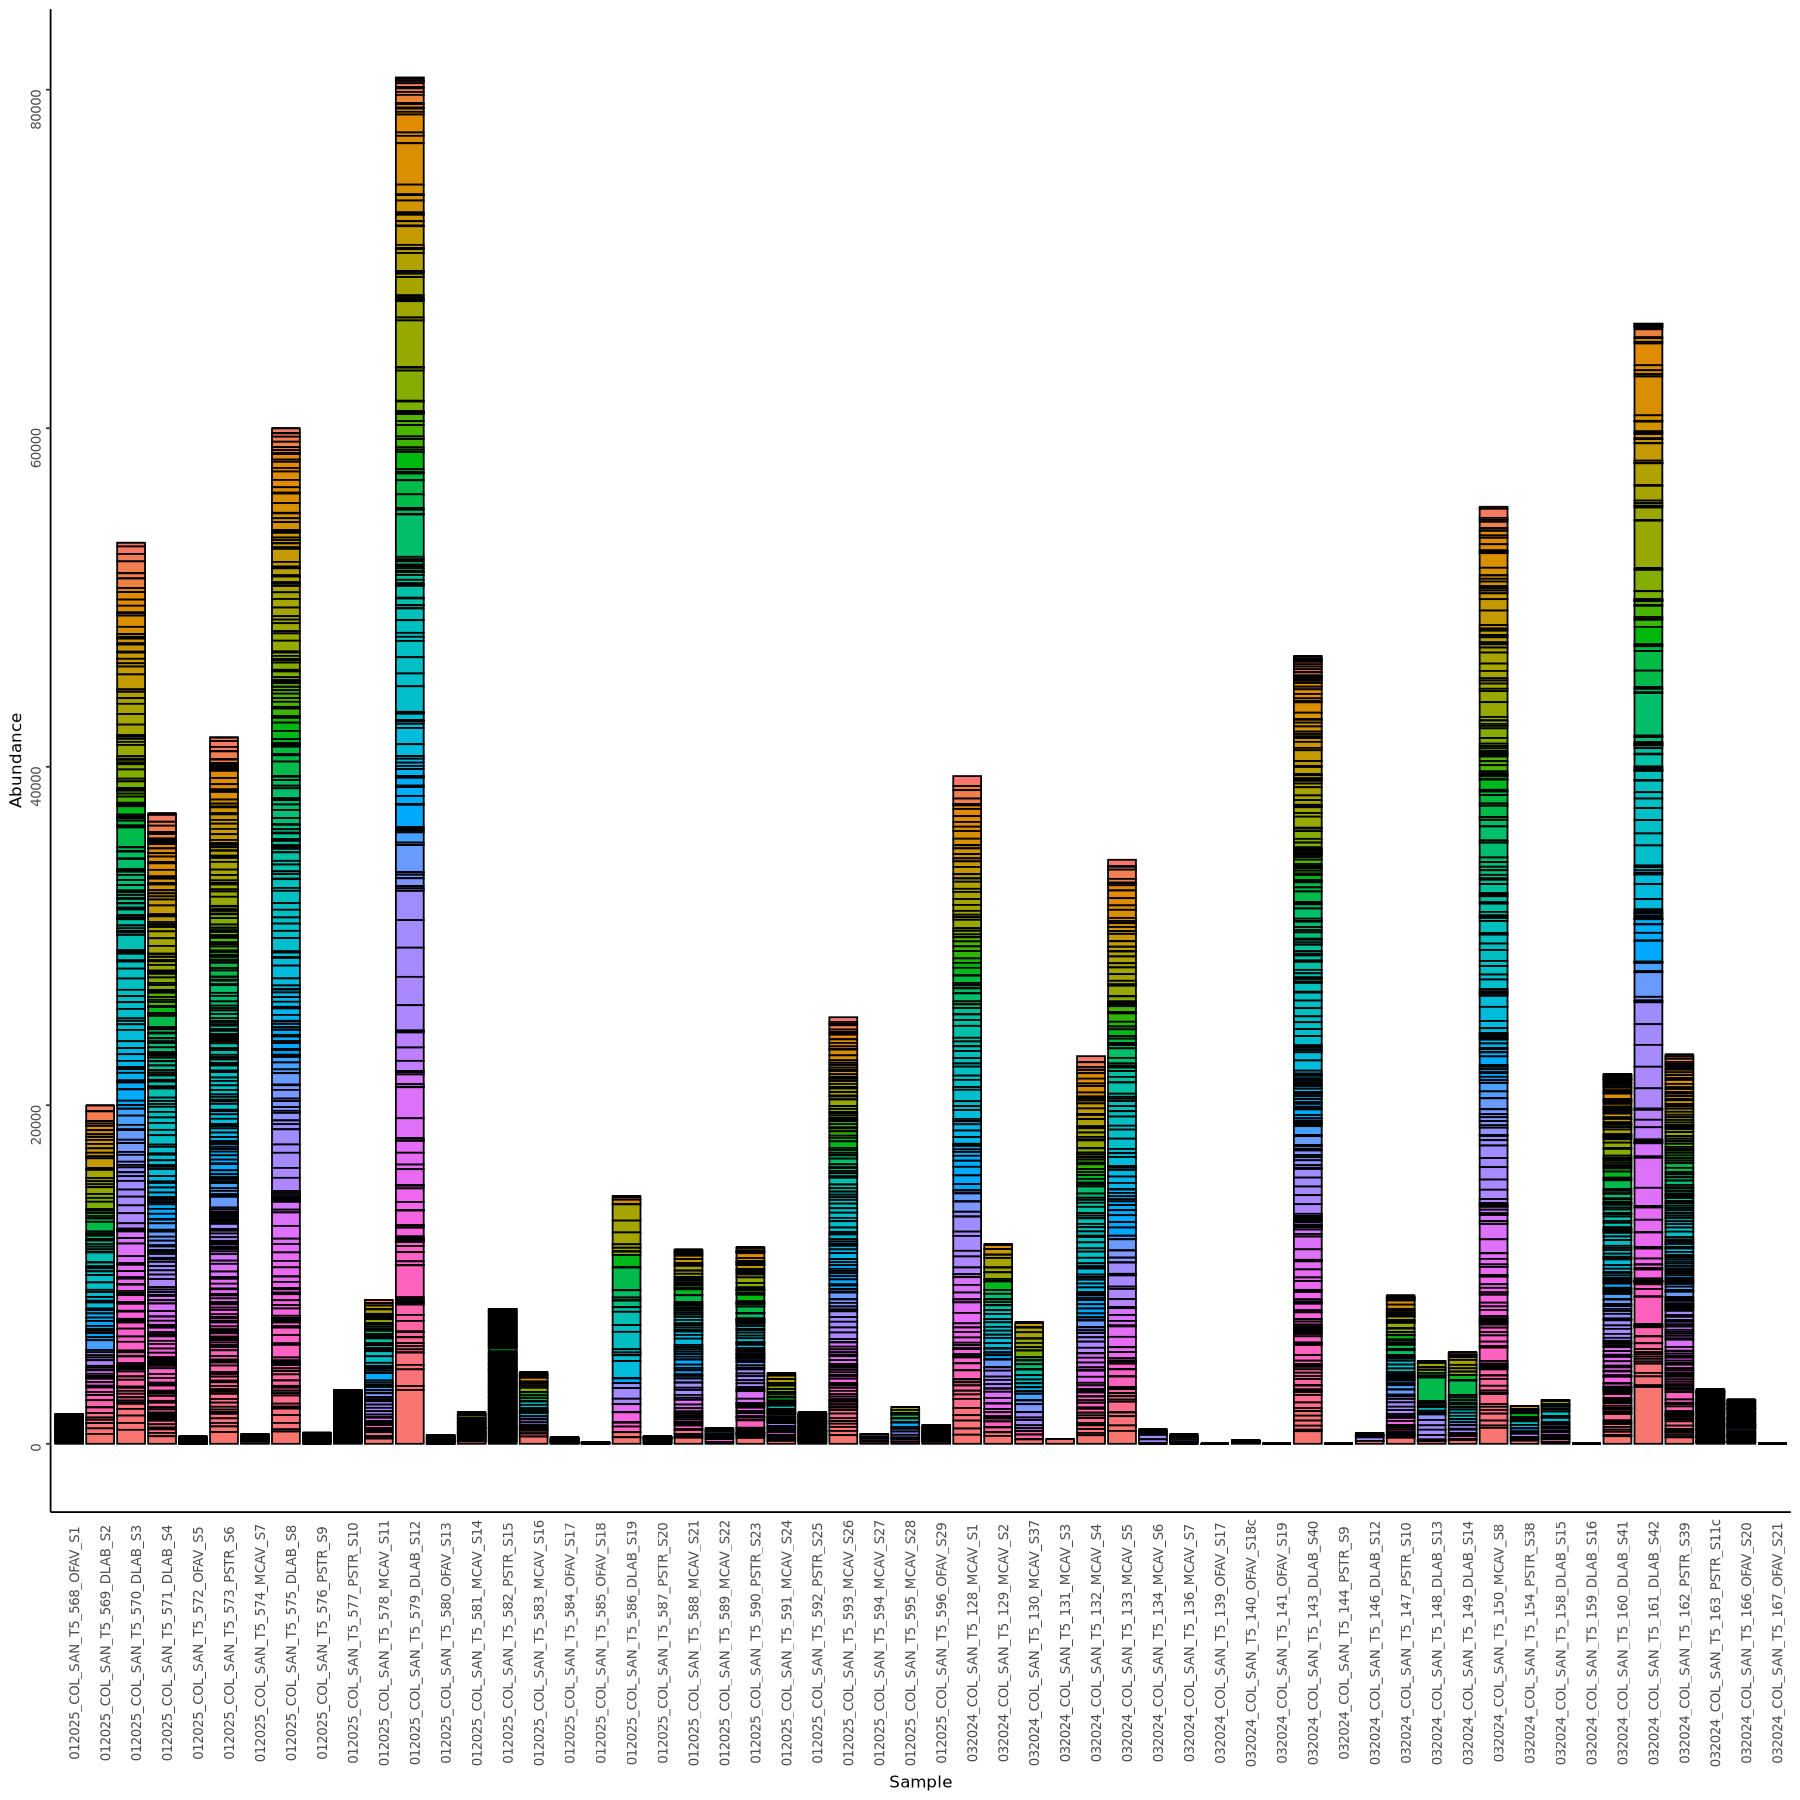

In [16]:
pathway_plot<- df_pathway_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position = "none", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(),
          panel.grid.minor.y = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=10))
pathway_plot

In [17]:
ggsave(filename = "pathway_plot_all_samples_cpm.png", plot = pathway_plot, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

### Combine samples of same coral species and sample year together

In [18]:
#combine samples into 012025 and 032024 groupings for each species
# Summing specific columns by name
pathway_totals <- as.data.frame(pathways_filt_reordered)
pathway_totals$OFAV_032024 <- rowSums(pathways_filt_reordered[, c("032024_COL_SAN_T5_139_OFAV_S17","032024_COL_SAN_T5_140_OFAV_S18c",
                                                                 "032024_COL_SAN_T5_141_OFAV_S19","032024_COL_SAN_T5_166_OFAV_S20",
                                                                 "032024_COL_SAN_T5_167_OFAV_S21")], 
                          na.rm = TRUE)
pathway_totals$OFAV_012025 <- rowSums(pathways_filt_reordered[, c("012025_COL_SAN_T5_568_OFAV_S1","012025_COL_SAN_T5_572_OFAV_S5",
                                                                  "012025_COL_SAN_T5_580_OFAV_S13","012025_COL_SAN_T5_584_OFAV_S17",
                                                                  "012025_COL_SAN_T5_585_OFAV_S18","012025_COL_SAN_T5_596_OFAV_S29")], 
                          na.rm = TRUE)
pathway_totals$MCAV_032024 <- rowSums(pathways_filt_reordered[, c("032024_COL_SAN_T5_128_MCAV_S1","032024_COL_SAN_T5_129_MCAV_S2",
                                                                  "032024_COL_SAN_T5_130_MCAV_S37","032024_COL_SAN_T5_131_MCAV_S3",
                                                                  "032024_COL_SAN_T5_132_MCAV_S4","032024_COL_SAN_T5_133_MCAV_S5",
                                                                  "032024_COL_SAN_T5_134_MCAV_S6","032024_COL_SAN_T5_136_MCAV_S7",
                                                                  "032024_COL_SAN_T5_150_MCAV_S8")], 
                          na.rm = TRUE)
pathway_totals$MCAV_012025 <- rowSums(pathways_filt_reordered[, c("012025_COL_SAN_T5_574_MCAV_S7","012025_COL_SAN_T5_578_MCAV_S11",
                                                                  "012025_COL_SAN_T5_581_MCAV_S14","012025_COL_SAN_T5_583_MCAV_S16",
                                                                  "012025_COL_SAN_T5_588_MCAV_S21","012025_COL_SAN_T5_589_MCAV_S22",
                                                                  "012025_COL_SAN_T5_591_MCAV_S24","012025_COL_SAN_T5_593_MCAV_S26",
                                                                  "012025_COL_SAN_T5_594_MCAV_S27","012025_COL_SAN_T5_595_MCAV_S28")], 
                          na.rm = TRUE)
pathway_totals$DLAB_032024 <- rowSums(pathways_filt_reordered[, c("032024_COL_SAN_T5_146_DLAB_S12","032024_COL_SAN_T5_148_DLAB_S13",
                                                                  "032024_COL_SAN_T5_149_DLAB_S14","032024_COL_SAN_T5_158_DLAB_S15",
                                                                  "032024_COL_SAN_T5_159_DLAB_S16","032024_COL_SAN_T5_143_DLAB_S40",
                                                                  "032024_COL_SAN_T5_160_DLAB_S41","032024_COL_SAN_T5_161_DLAB_S42")], 
                          na.rm = TRUE)
pathway_totals$DLAB_012025 <- rowSums(pathways_filt_reordered[, c("012025_COL_SAN_T5_569_DLAB_S2","012025_COL_SAN_T5_570_DLAB_S3",
                                                                  "012025_COL_SAN_T5_571_DLAB_S4","012025_COL_SAN_T5_575_DLAB_S8",
                                                                  "012025_COL_SAN_T5_579_DLAB_S12","012025_COL_SAN_T5_586_DLAB_S19")], 
                          na.rm = TRUE)
pathway_totals$PSTR_032024 <- rowSums(pathways_filt_reordered[, c("032024_COL_SAN_T5_144_PSTR_S9","032024_COL_SAN_T5_147_PSTR_S10",
                                                                 "032024_COL_SAN_T5_163_PSTR_S11c","032024_COL_SAN_T5_154_PSTR_S38",
                                                                 "032024_COL_SAN_T5_162_PSTR_S39")], 
                          na.rm = TRUE)
pathway_totals$PSTR_012025 <- rowSums(pathways_filt_reordered[, c("012025_COL_SAN_T5_573_PSTR_S6","012025_COL_SAN_T5_576_PSTR_S9",
                                                                 "012025_COL_SAN_T5_577_PSTR_S10","012025_COL_SAN_T5_582_PSTR_S15",
                                                                 "012025_COL_SAN_T5_587_PSTR_S20","012025_COL_SAN_T5_590_PSTR_S23",
                                                                 "012025_COL_SAN_T5_592_PSTR_S25")], 
                          na.rm = TRUE)

head(pathway_totals)

,Pathway,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,⋯,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25,OFAV_032024,OFAV_012025,MCAV_032024,MCAV_012025,DLAB_032024,DLAB_012025,PSTR_032024,PSTR_012025
,<chr>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0,0,0,0,0,0,0,0,⋯,0.0000,0,0,0,0.0000,0.000,61.7501,0.0000,0.000,23.4657
8,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0,0,0,0,0,0,0,0,0,⋯,0.0000,0,0,0,0.0000,0.000,98.5726,32.0572,0.000,0.0000
10,1CMET2-PWY: folate transformations III (E. coli),0,0,0,0,0,0,0,0,0,⋯,0.0000,0,0,0,83.5265,0.000,444.3952,901.1583,157.737,89.4499
14,ANAEROFRUCAT-PWY: homolactic fermentation,0,0,0,0,0,0,0,0,0,⋯,0.0000,0,0,0,510.6820,135.074,213.9287,294.7265,0.000,73.5769
16,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0,0,0,0,0,0,0,0,0,⋯,47.7729,0,0,0,1217.9680,277.262,435.7000,813.9150,0.000,158.2889
18,ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0,0,0,0,0,0,0,0,0,⋯,0.0000,0,0,0,0.0000,0.000,0.0000,0.0000,0.000,72.5046


In [19]:
#then remove the samples and just have the totals
pathway_totals_ready <- pathway_totals %>% select(-contains("_SAN_T5_"))
head(pathway_totals_ready)

,Pathway,OFAV_032024,OFAV_012025,MCAV_032024,MCAV_012025,DLAB_032024,DLAB_012025,PSTR_032024,PSTR_012025
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0,0.0000,0.000,61.7501,0.0000,0.000,23.4657
8,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0,0,0.0000,0.000,98.5726,32.0572,0.000,0.0000
10,1CMET2-PWY: folate transformations III (E. coli),0,0,83.5265,0.000,444.3952,901.1583,157.737,89.4499
14,ANAEROFRUCAT-PWY: homolactic fermentation,0,0,510.6820,135.074,213.9287,294.7265,0.000,73.5769
16,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0,0,1217.9680,277.262,435.7000,813.9150,0.000,158.2889
18,ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0,0,0.0000,0.000,0.0000,0.0000,0.000,72.5046


In [20]:
write.csv(pathway_totals_ready, file="pathway_totals_ready_cpm.csv")

In [21]:
df_pathway_totals_long <- pathway_totals_ready %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

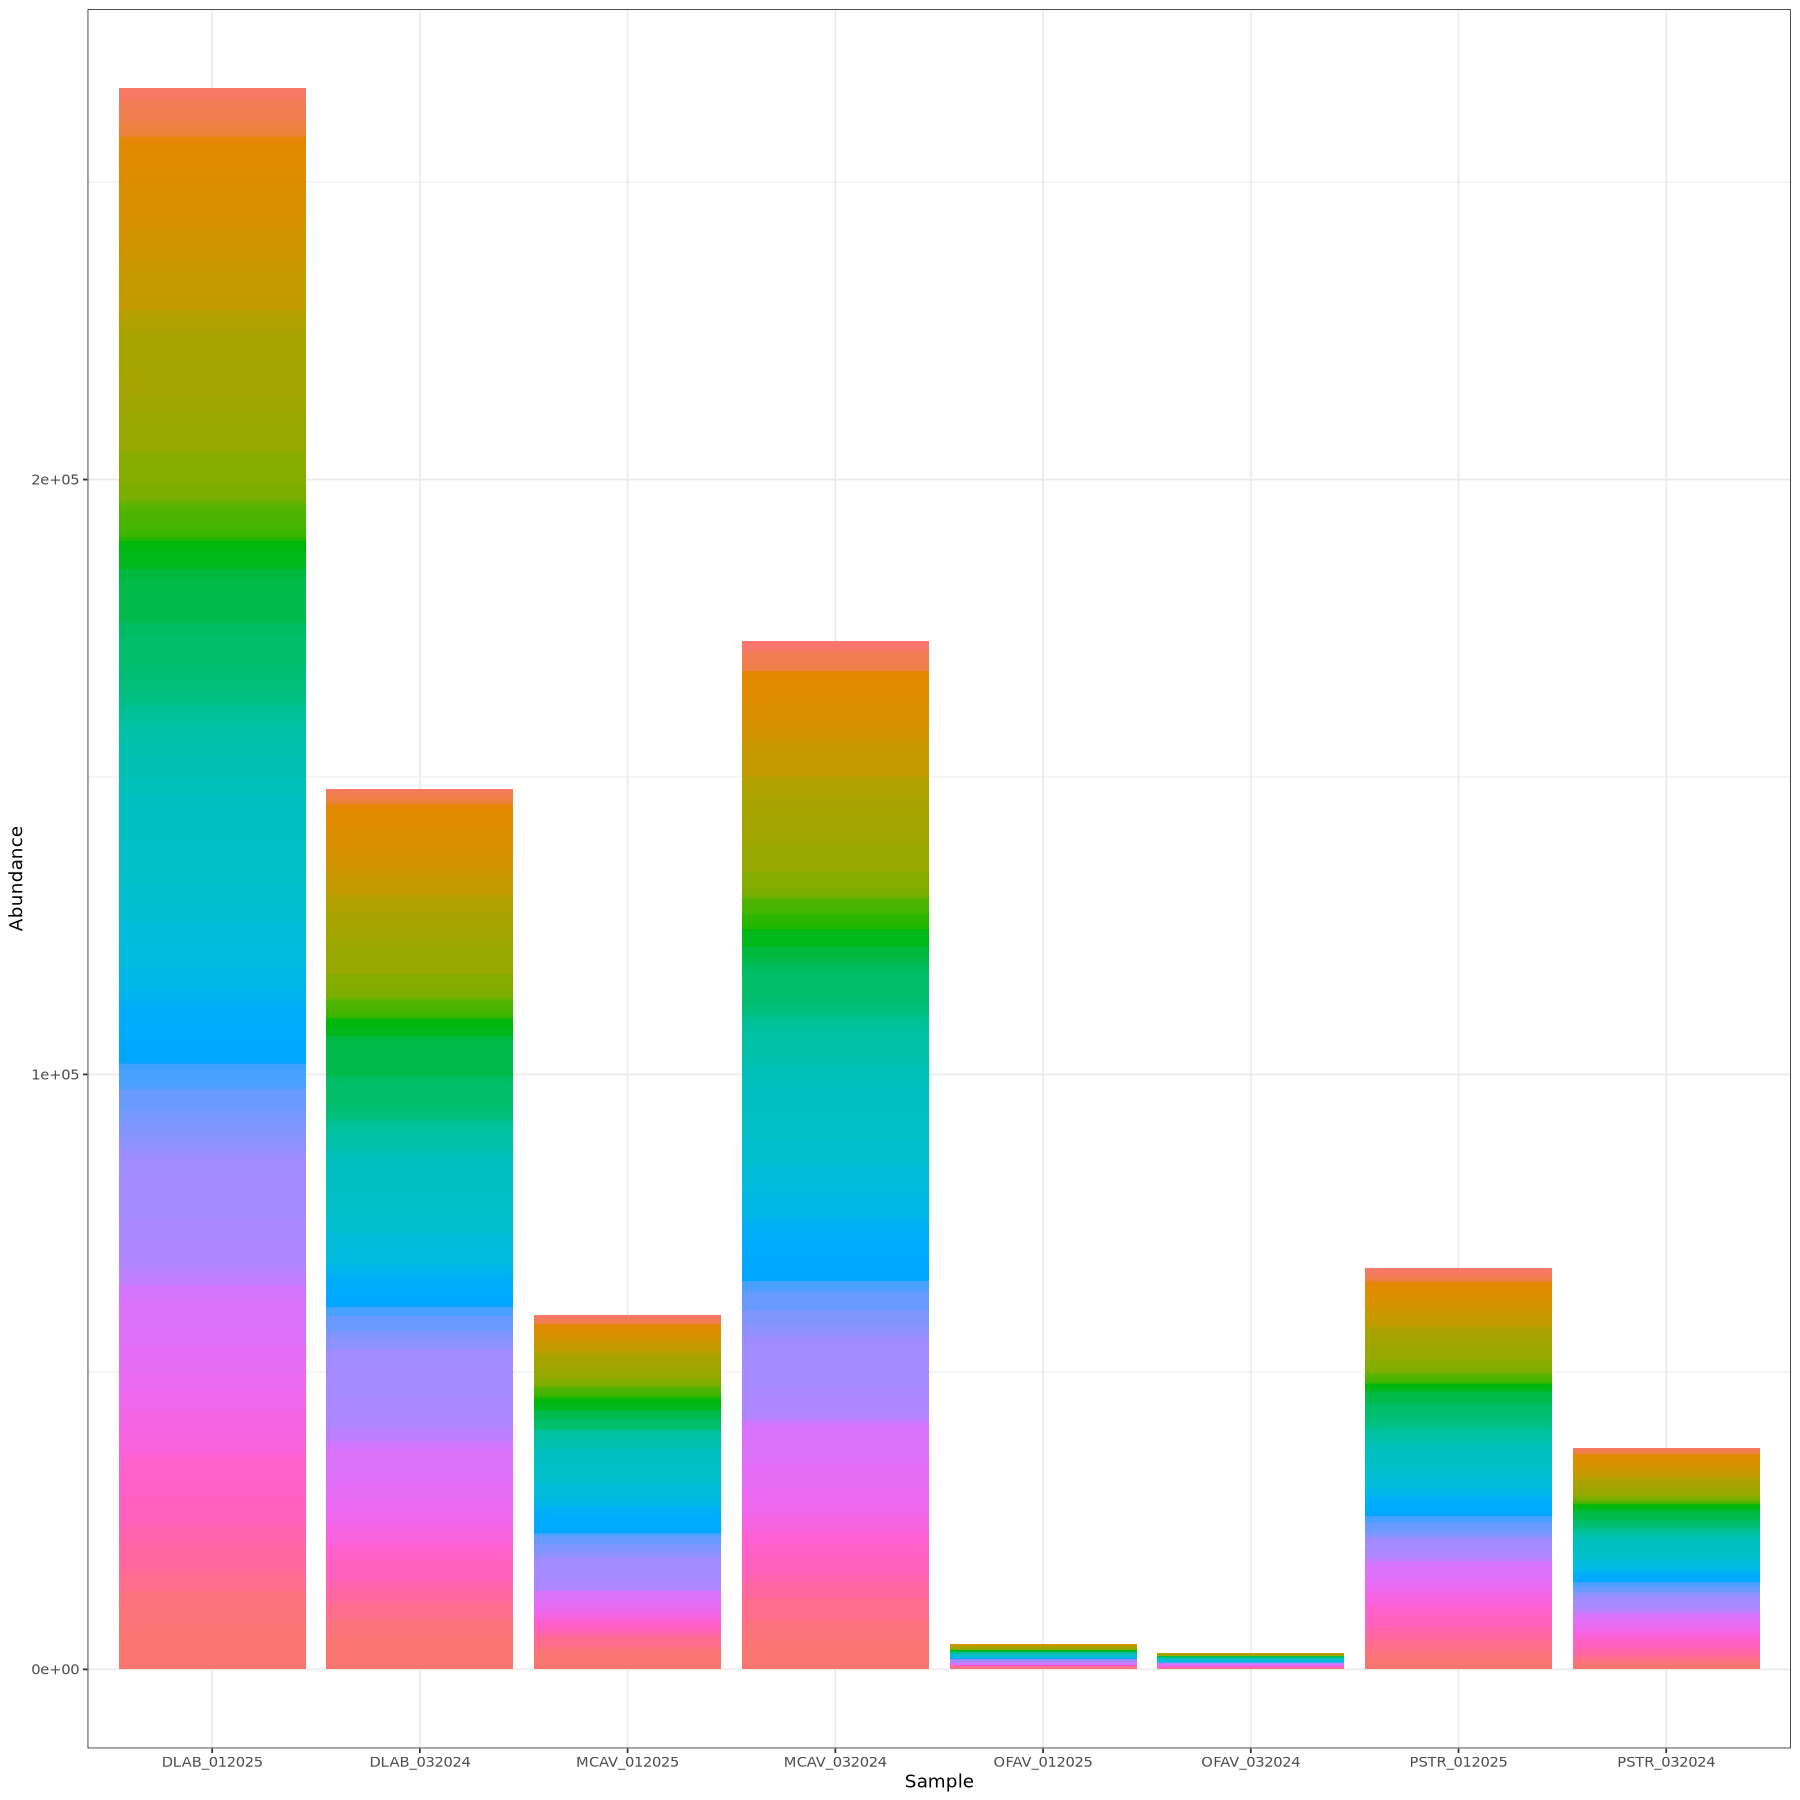

In [22]:
coral_pathway_plot<- df_pathway_totals_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), stat = "identity", position = "stack")+
  theme_bw()+
  theme(legend.position = "none")
coral_pathway_plot

### OFAVs

In [35]:
#look at just ofavs
ofav_pathways <- subset(pathway_totals_ready, select = c(Pathway, OFAV_032024, OFAV_012025))
head(ofav_pathways)
#remove rows with zeros (in columns 2 and 3)
ofav_pathways_num <- ofav_pathways[rowSums(ofav_pathways[, c(2,3)] == 0) < 2, ]
head(ofav_pathways_num)
dim(ofav_pathways_num)

,Pathway,OFAV_032024,OFAV_012025
,<chr>,<dbl>,<dbl>
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0
8,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0,0
10,1CMET2-PWY: folate transformations III (E. coli),0,0
14,ANAEROFRUCAT-PWY: homolactic fermentation,0,0
16,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0,0
18,ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0,0


,Pathway,OFAV_032024,OFAV_012025
,<chr>,<dbl>,<dbl>
20,ARGININE-SYN4-PWY: L-ornithine biosynthesis II,20.3561,0.0000
39,BRANCHED-CHAIN-AA-SYN-PWY: superpathway of branched chain amino acid biosynthesis,0.0000,182.5721
43,CALVIN-PWY: Calvin-Benson-Bassham cycle,0.0000,85.1485
59,COA-PWY: coenzyme A biosynthesis I (prokaryotic),60.7945,30.8338
81,FASYN-ELONG-PWY: fatty acid elongation -- saturated,115.3210,40.3640
110,GLUTORN-PWY: L-ornithine biosynthesis I,28.7184,46.9314


[1] 82  3

In [24]:
df_pathway_ofav_long <- ofav_pathways_num %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

In [25]:
options(repr.plot.width=10, repr.plot.height=10)

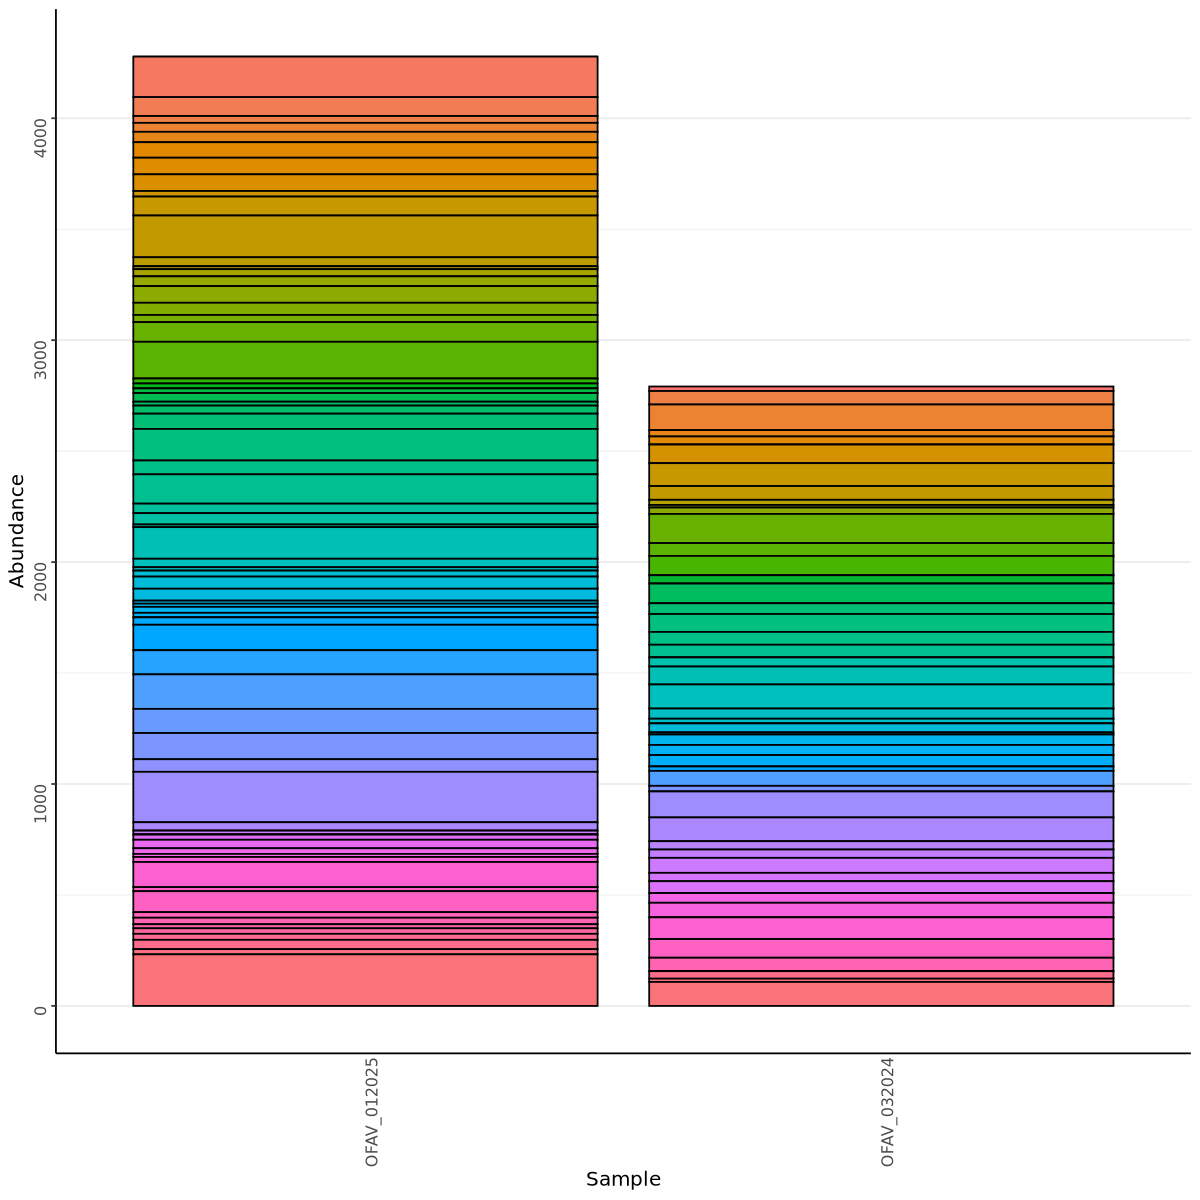

In [27]:
ofav_pathway_plot<- df_pathway_ofav_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position="none", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12)) 
#legend.key.size = unit(0.1, "cm"))+
#theme(aspect.ratio = 1.5)

ofav_pathway_plot

In [28]:
ggsave(filename = "ofav_pathway_plot_all_cpm.png", plot = ofav_pathway_plot, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

In [29]:
# index the Pathways
row.names(ofav_pathways_num) <- ofav_pathways_num$Pathway
ofav_pathways_num$Pathway <- NULL
head(ofav_pathways_num)

,OFAV_032024,OFAV_012025
,<dbl>,<dbl>
ARGININE-SYN4-PWY: L-ornithine biosynthesis II,20.3561,0.0000
BRANCHED-CHAIN-AA-SYN-PWY: superpathway of branched chain amino acid biosynthesis,0.0000,182.5721
CALVIN-PWY: Calvin-Benson-Bassham cycle,0.0000,85.1485
COA-PWY: coenzyme A biosynthesis I (prokaryotic),60.7945,30.8338
FASYN-ELONG-PWY: fatty acid elongation -- saturated,115.3210,40.3640
GLUTORN-PWY: L-ornithine biosynthesis I,28.7184,46.9314


In [30]:
# Convert to matrix
ofav_pathways_matrix=as.matrix(ofav_pathways_num)
head(ofav_pathways_matrix)

,OFAV_032024,OFAV_012025
ARGININE-SYN4-PWY: L-ornithine biosynthesis II,20.3561,0.0000
BRANCHED-CHAIN-AA-SYN-PWY: superpathway of branched chain amino acid biosynthesis,0.0000,182.5721
CALVIN-PWY: Calvin-Benson-Bassham cycle,0.0000,85.1485
COA-PWY: coenzyme A biosynthesis I (prokaryotic),60.7945,30.8338
FASYN-ELONG-PWY: fatty acid elongation -- saturated,115.3210,40.3640
GLUTORN-PWY: L-ornithine biosynthesis I,28.7184,46.9314


In [31]:
#calculate totals
pathway_totals <- rowSums(ofav_pathways_matrix)

In [32]:
#take the top 20 pathways
ofav_top_20 <- order(pathway_totals, decreasing = TRUE)[1:20]
head(ofav_top_20)

[1] 59 82 13 24 34 40

In [37]:
#need to do this from an unindexed dataframe, so re-run step where I first make the ofav_pathways_num df
    #before doing this part!
#pull the top 20 out of the full matrix
ofav_top_20_m <- ofav_pathways_num[ofav_top_20, ]
head(ofav_top_20_m )

,Pathway,OFAV_032024,OFAV_012025
,<chr>,<dbl>,<dbl>
674,PWY-7663: gondoate biosynthesis (anaerobic),117.0450,227.3134
863,VALSYN-PWY: L-valine biosynthesis,108.2047,232.4188
151,ILEUSYN-PWY: L-isoleucine biosynthesis I (from threonine),62.0912,188.3161
286,PWY-5103: L-isoleucine biosynthesis III,57.9721,165.6580
397,PWY-6122: 5-aminoimidazole ribonucleotide biosynthesis II,80.7588,142.3822
439,PWY-6277: superpathway of 5-aminoimidazole ribonucleotide biosynthesis,80.7588,142.3822


In [38]:
df_pathway_ofav_20_long <- ofav_top_20_m %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

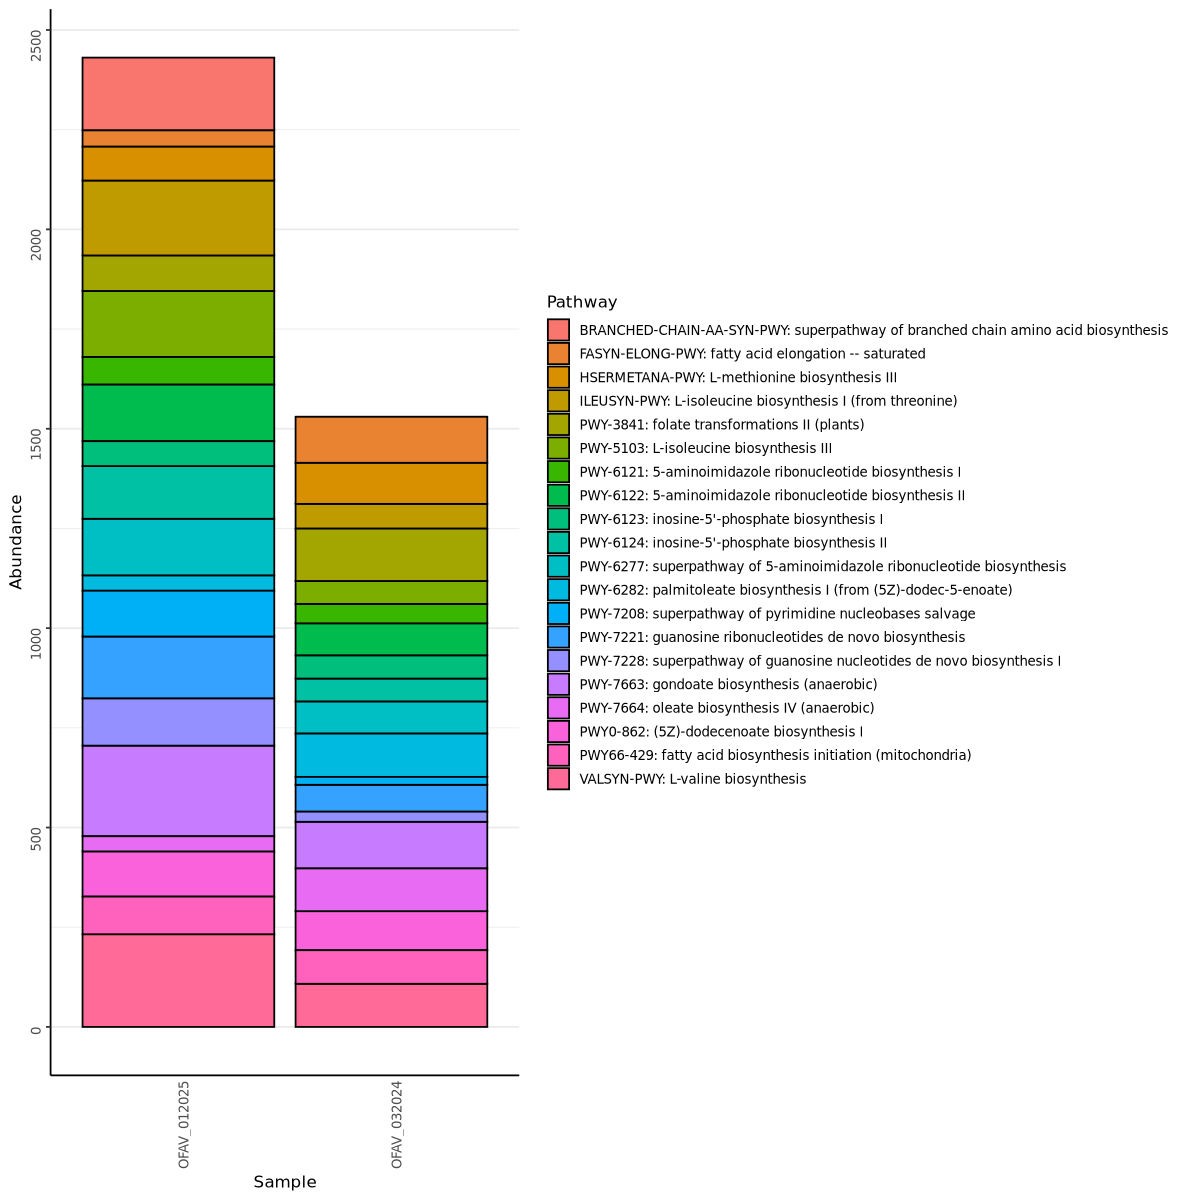

In [39]:
ofav_pathway_plot_20<- df_pathway_ofav_20_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position="right", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=10), legend.key.size = unit(0.5, "cm")) 
#theme(aspect.ratio = 1.5)

ofav_pathway_plot_20

In [40]:
ggsave(filename = "ofav_pathway_plot_20_cpm.png", plot = ofav_pathway_plot_20, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

In [41]:
df_pathway_ofav_20_rel <- as.data.frame(ofav_top_20_m) %>%
  mutate(across(where(is.numeric), ~ .x / sum(.x)))
head(df_pathway_ofav_20_rel)

,Pathway,OFAV_032024,OFAV_012025
,<chr>,<dbl>,<dbl>
674,PWY-7663: gondoate biosynthesis (anaerobic),0.07649946,0.09351690
863,VALSYN-PWY: L-valine biosynthesis,0.07072152,0.09561727
151,ILEUSYN-PWY: L-isoleucine biosynthesis I (from threonine),0.04058219,0.07747339
286,PWY-5103: L-isoleucine biosynthesis III,0.03788999,0.06815183
397,PWY-6122: 5-aminoimidazole ribonucleotide biosynthesis II,0.05278315,0.05857614
439,PWY-6277: superpathway of 5-aminoimidazole ribonucleotide biosynthesis,0.05278315,0.05857614


In [42]:
df_pathway_ofav_20_rel_long <- df_pathway_ofav_20_rel %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

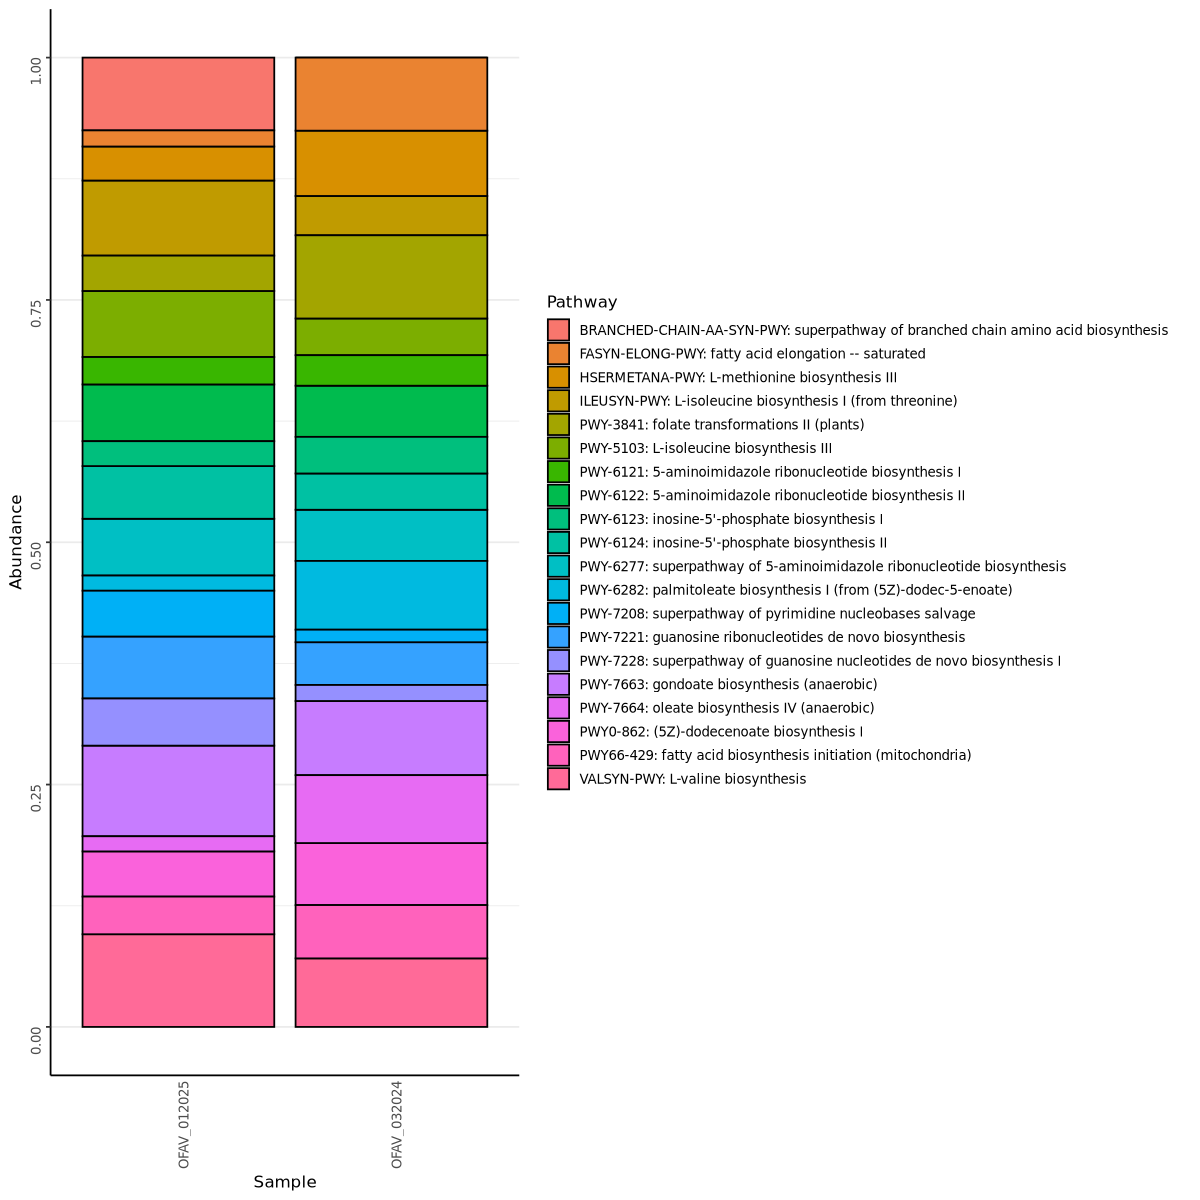

In [43]:
ofav_pathway_plot_20_rel<- df_pathway_ofav_20_rel_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position="right", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=10), legend.key.size = unit(0.5, "cm")) 
#theme(aspect.ratio = 1.5)

ofav_pathway_plot_20_rel

In [44]:
ggsave(filename = "ofav_pathway_plot_20_rel_cpm.png", plot = ofav_pathway_plot_20_rel, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

### MCAVs

In [52]:
#look at just mcavs
mcav_pathways <- subset(pathway_totals_ready, select = c(Pathway, MCAV_032024, MCAV_012025))
head(mcav_pathways)
#remove rows with zeros (in columns 2 and 3)
mcav_pathways_num <- mcav_pathways[rowSums(mcav_pathways[, c(2,3)] == 0) < 2, ]
head(mcav_pathways_num)
dim(mcav_pathways_num)

,Pathway,MCAV_032024,MCAV_012025
,<chr>,<dbl>,<dbl>
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0.0000,0.000
8,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0.0000,0.000
10,1CMET2-PWY: folate transformations III (E. coli),83.5265,0.000
14,ANAEROFRUCAT-PWY: homolactic fermentation,510.6820,135.074
16,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),1217.9680,277.262
18,ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0.0000,0.000


,Pathway,MCAV_032024,MCAV_012025
,<chr>,<dbl>,<dbl>
10,1CMET2-PWY: folate transformations III (E. coli),83.5265,0.000
14,ANAEROFRUCAT-PWY: homolactic fermentation,510.6820,135.074
16,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),1217.9680,277.262
20,ARGININE-SYN4-PWY: L-ornithine biosynthesis II,131.7430,0.000
23,ARGSYN-PWY: L-arginine biosynthesis I (via L-ornithine),1489.0550,209.275
27,ARGSYNBSUB-PWY: L-arginine biosynthesis II (acetyl cycle),1355.9660,328.381


[1] 221   3

In [46]:
df_pathway_mcav_long <- mcav_pathways_num %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

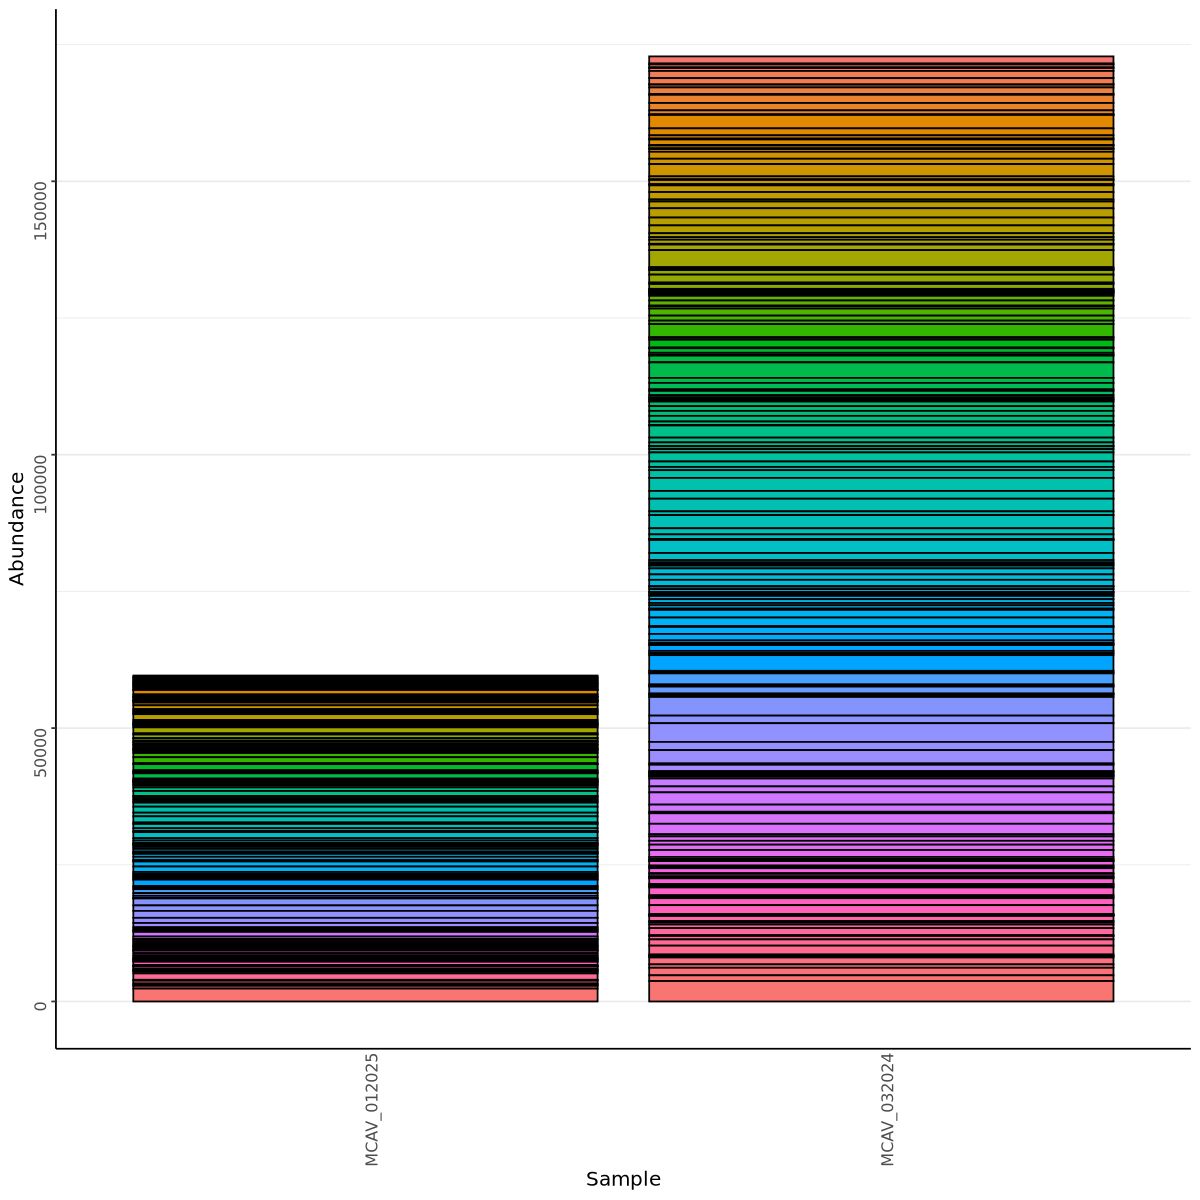

In [47]:
#without legend - need to play with sizing
mcav_pathway_plot_l<- df_pathway_mcav_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position="none", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12)) 
mcav_pathway_plot_l

In [48]:
# index the Pathways
row.names(mcav_pathways_num) <- mcav_pathways_num$Pathway
mcav_pathways_num$Pathway <- NULL
head(mcav_pathways_num)

,MCAV_032024,MCAV_012025
,<dbl>,<dbl>
1CMET2-PWY: folate transformations III (E. coli),83.5265,0.000
ANAEROFRUCAT-PWY: homolactic fermentation,510.6820,135.074
ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),1217.9680,277.262
ARGININE-SYN4-PWY: L-ornithine biosynthesis II,131.7430,0.000
ARGSYN-PWY: L-arginine biosynthesis I (via L-ornithine),1489.0550,209.275
ARGSYNBSUB-PWY: L-arginine biosynthesis II (acetyl cycle),1355.9660,328.381


In [49]:
# Convert to matrix
mcav_pathways_matrix=as.matrix(mcav_pathways_num)
head(mcav_pathways_matrix)

,MCAV_032024,MCAV_012025
1CMET2-PWY: folate transformations III (E. coli),83.5265,0.000
ANAEROFRUCAT-PWY: homolactic fermentation,510.6820,135.074
ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),1217.9680,277.262
ARGININE-SYN4-PWY: L-ornithine biosynthesis II,131.7430,0.000
ARGSYN-PWY: L-arginine biosynthesis I (via L-ornithine),1489.0550,209.275
ARGSYNBSUB-PWY: L-arginine biosynthesis II (acetyl cycle),1355.9660,328.381


In [50]:
#calculate totals
pathway_totals_m <- rowSums(mcav_pathways_matrix)

In [51]:
#take the top 20 pathways
mcav_top_20 <- order(pathway_totals_m, decreasing = TRUE)[1:20]
head(mcav_top_20)

[1] 221 152 154  39 139  73

In [53]:
#need to do this from an unindexed dataframe, so re-run step where I first make the ofav_pathways_num df
    #before doing this part!
#pull the top 20 out of the full matrix
mcav_top_20_m <- mcav_pathways_num[mcav_top_20, ]
head(mcav_top_20_m)

,Pathway,MCAV_032024,MCAV_012025
,<chr>,<dbl>,<dbl>
863,VALSYN-PWY: L-valine biosynthesis,3738.568,2357.293
590,PWY-7220: adenosine deoxyribonucleotides de novo biosynthesis II,3415.102,1269.893
598,PWY-7222: guanosine deoxyribonucleotides de novo biosynthesis II,3415.102,1269.893
151,ILEUSYN-PWY: L-isoleucine biosynthesis I (from threonine),3122.334,1143.934
552,PWY-7111: pyruvate fermentation to isobutanol (engineered),2868.697,1167.789
286,PWY-5103: L-isoleucine biosynthesis III,2830.331,960.868


In [54]:
df_pathway_mcav_20_long <- mcav_top_20_m %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

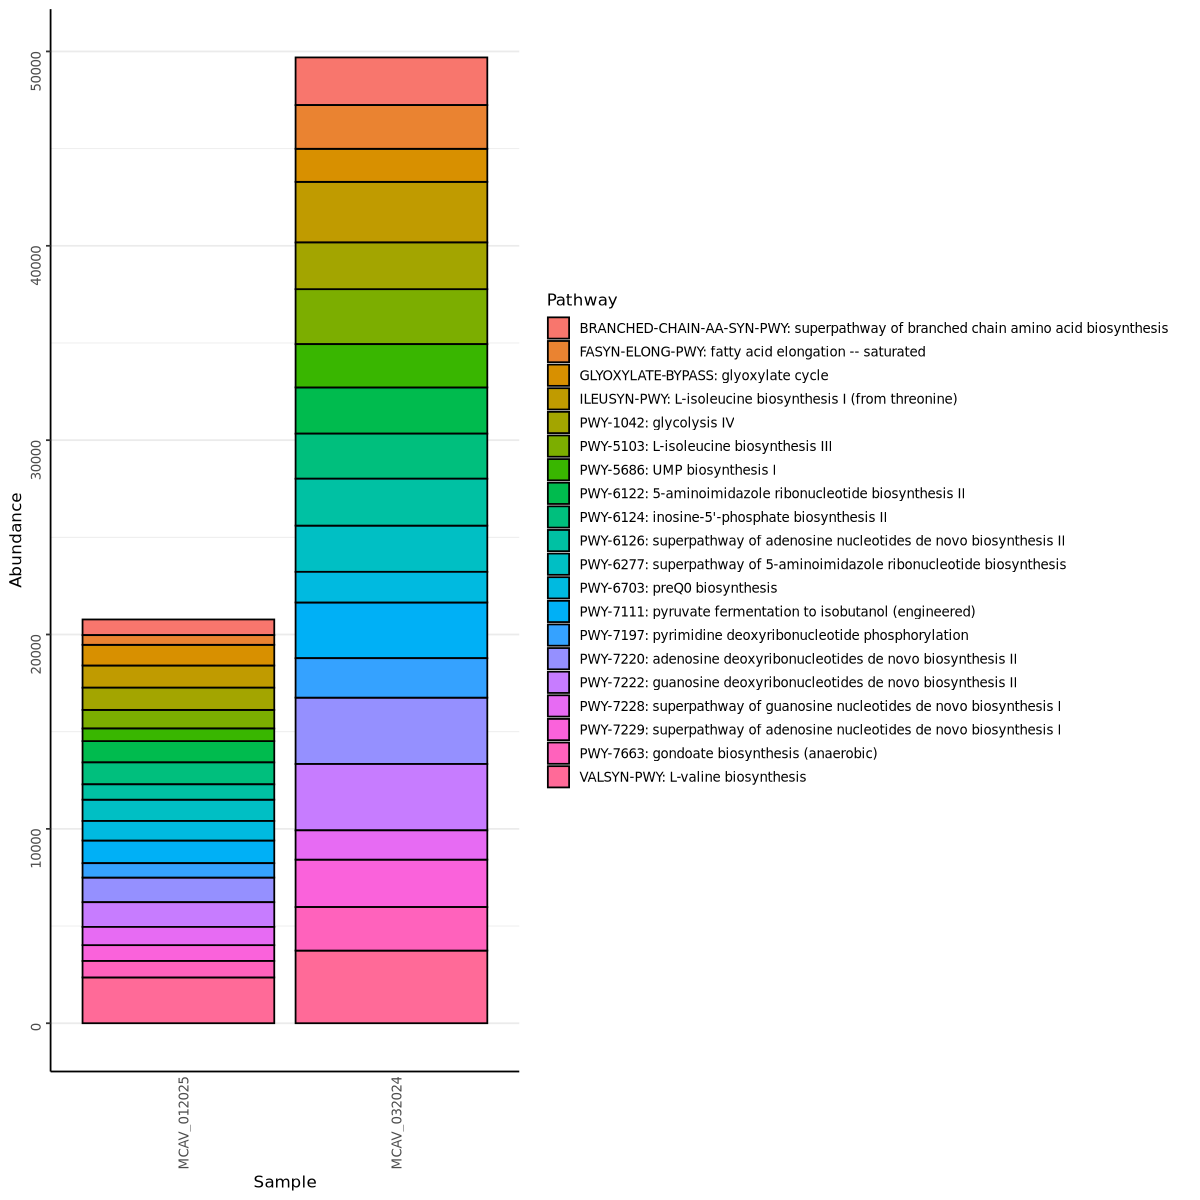

In [55]:
mcav_pathway_plot_20<- df_pathway_mcav_20_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position="right", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=10), legend.key.size = unit(0.5, "cm"))
#theme(aspect.ratio = 1.5)

mcav_pathway_plot_20

In [56]:
ggsave(filename = "mcav_pathway_plot_20_cpm.png", plot = mcav_pathway_plot_20, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

In [57]:
df_pathway_mcav_20_rel <- as.data.frame(mcav_top_20_m) %>%
  mutate(across(where(is.numeric), ~ .x / sum(.x)))
head(df_pathway_mcav_20_rel)

,Pathway,MCAV_032024,MCAV_012025
,<chr>,<dbl>,<dbl>
863,VALSYN-PWY: L-valine biosynthesis,0.07523483,0.11347312
590,PWY-7220: adenosine deoxyribonucleotides de novo biosynthesis II,0.06872541,0.06112891
598,PWY-7222: guanosine deoxyribonucleotides de novo biosynthesis II,0.06872541,0.06112891
151,ILEUSYN-PWY: L-isoleucine biosynthesis I (from threonine),0.06283376,0.05506560
552,PWY-7111: pyruvate fermentation to isobutanol (engineered),0.05772957,0.05621391
286,PWY-5103: L-isoleucine biosynthesis III,0.05695750,0.04625335


In [58]:
df_pathway_mcav_20_rel_long <- df_pathway_mcav_20_rel %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

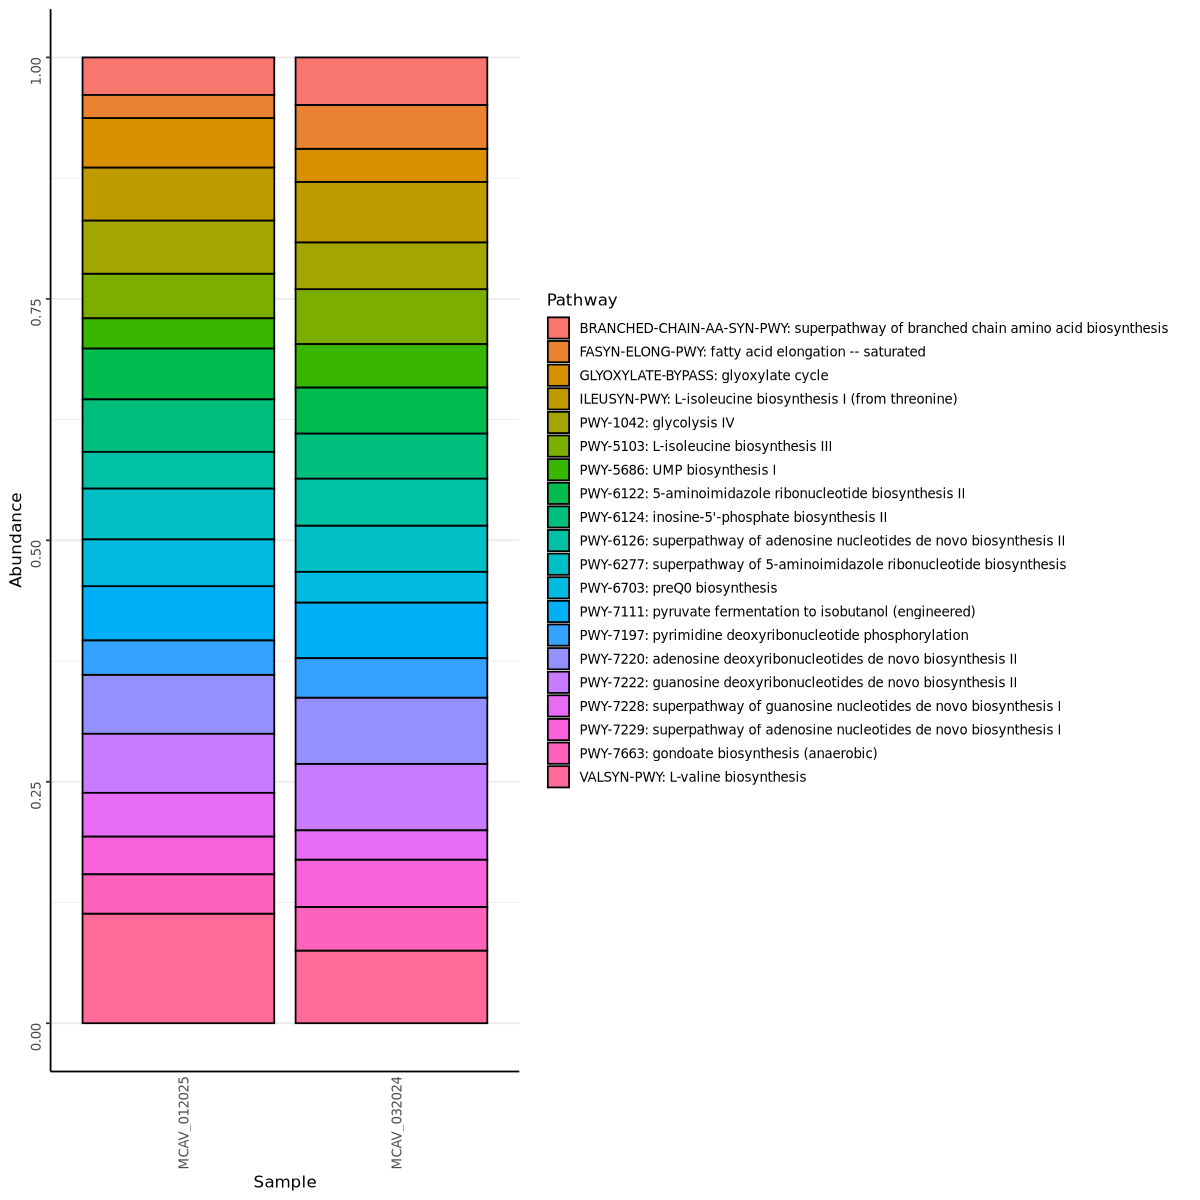

In [59]:
mcav_pathway_plot_20_rel<- df_pathway_mcav_20_rel_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position="right", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=10), legend.key.size = unit(0.5, "cm"))
#theme(aspect.ratio = 1.5)

mcav_pathway_plot_20_rel

In [60]:
ggsave(filename = "mcav_pathway_plot_20_rel_cpm.png", plot = mcav_pathway_plot_20_rel, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

### DLABs

In [68]:
#look at just dlabs
dlab_pathways <- subset(pathway_totals_ready, select = c(Pathway, DLAB_032024, DLAB_012025))
head(dlab_pathways)
#remove rows with zeros (in columns 2 and 3)
dlab_pathways_num <- dlab_pathways[rowSums(dlab_pathways[, c(2,3)] == 0) < 2, ]
head(dlab_pathways_num)
dim(dlab_pathways_num)

,Pathway,DLAB_032024,DLAB_012025
,<chr>,<dbl>,<dbl>
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",61.7501,0.0000
8,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",98.5726,32.0572
10,1CMET2-PWY: folate transformations III (E. coli),444.3952,901.1583
14,ANAEROFRUCAT-PWY: homolactic fermentation,213.9287,294.7265
16,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),435.7000,813.9150
18,ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0.0000,0.0000


,Pathway,DLAB_032024,DLAB_012025
,<chr>,<dbl>,<dbl>
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",61.7501,0.0000
8,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",98.5726,32.0572
10,1CMET2-PWY: folate transformations III (E. coli),444.3952,901.1583
14,ANAEROFRUCAT-PWY: homolactic fermentation,213.9287,294.7265
16,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),435.7000,813.9150
20,ARGININE-SYN4-PWY: L-ornithine biosynthesis II,238.5367,368.8710


[1] 310   3

In [62]:
df_pathway_dlab_long <- dlab_pathways_num %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

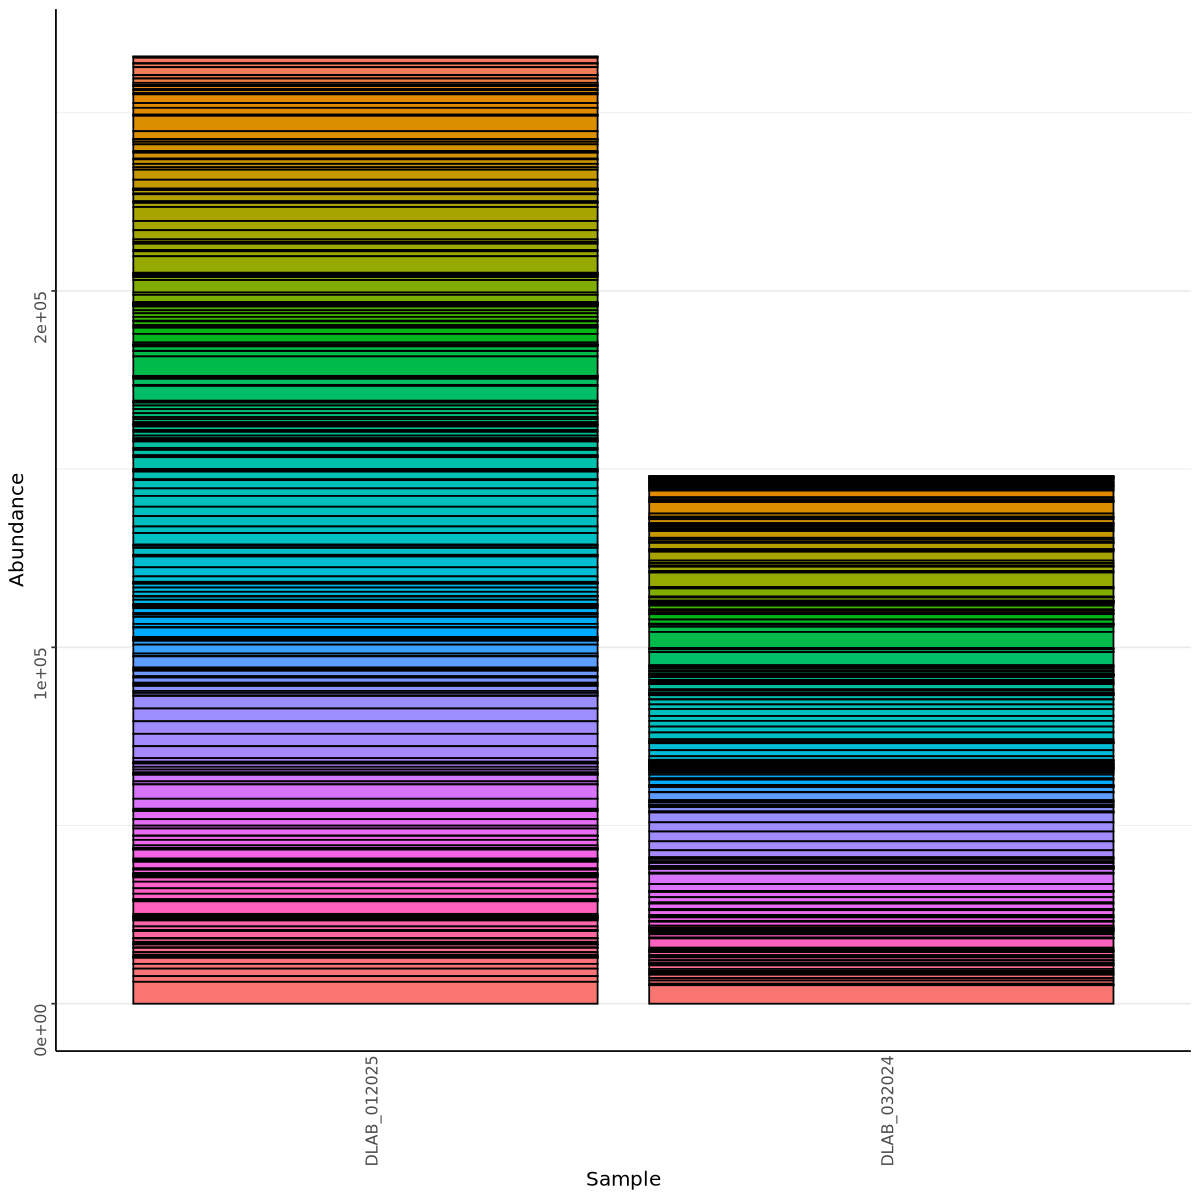

In [63]:
#without legend - need to play with sizing
dlab_pathway_plot_l<- df_pathway_dlab_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position="none", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12)) 
dlab_pathway_plot_l

In [64]:
# index the Pathways
row.names(dlab_pathways_num) <- dlab_pathways_num$Pathway
dlab_pathways_num$Pathway <- NULL
head(dlab_pathways_num)

,DLAB_032024,DLAB_012025
,<dbl>,<dbl>
"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",61.7501,0.0000
"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",98.5726,32.0572
1CMET2-PWY: folate transformations III (E. coli),444.3952,901.1583
ANAEROFRUCAT-PWY: homolactic fermentation,213.9287,294.7265
ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),435.7000,813.9150
ARGININE-SYN4-PWY: L-ornithine biosynthesis II,238.5367,368.8710


In [65]:
# Convert to matrix
dlab_pathways_matrix=as.matrix(dlab_pathways_num)
head(dlab_pathways_matrix)

,DLAB_032024,DLAB_012025
"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",61.7501,0.0000
"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",98.5726,32.0572
1CMET2-PWY: folate transformations III (E. coli),444.3952,901.1583
ANAEROFRUCAT-PWY: homolactic fermentation,213.9287,294.7265
ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),435.7000,813.9150
ARGININE-SYN4-PWY: L-ornithine biosynthesis II,238.5367,368.8710


In [66]:
#calculate totals
pathway_totals_d <- rowSums(dlab_pathways_matrix)

In [67]:
#take the top 20 pathways
dlab_top_20 <- order(pathway_totals_d, decreasing = TRUE)[1:20]
head(dlab_top_20)

[1] 310  95  53 103  12 239

In [69]:
#need to do this from an unindexed dataframe, so re-run step where I first make the ofav_pathways_num df
    #before doing this part!
#pull the top 20 out of the full matrix
dlab_top_20_m <- dlab_pathways_num[dlab_top_20, ]
head(dlab_top_20_m)

,Pathway,DLAB_032024,DLAB_012025
,<chr>,<dbl>,<dbl>
863,VALSYN-PWY: L-valine biosynthesis,5181.721,6138.690
260,PWY-3841: folate transformations II (plants),4537.938,5445.717
151,ILEUSYN-PWY: L-isoleucine biosynthesis I (from threonine),4125.886,4624.528
286,PWY-5103: L-isoleucine biosynthesis III,3680.251,4151.000
39,BRANCHED-CHAIN-AA-SYN-PWY: superpathway of branched chain amino acid biosynthesis,3217.126,4326.806
674,PWY-7663: gondoate biosynthesis (anaerobic),2911.704,4010.999


In [70]:
df_pathway_dlab_20_long <- dlab_top_20_m %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

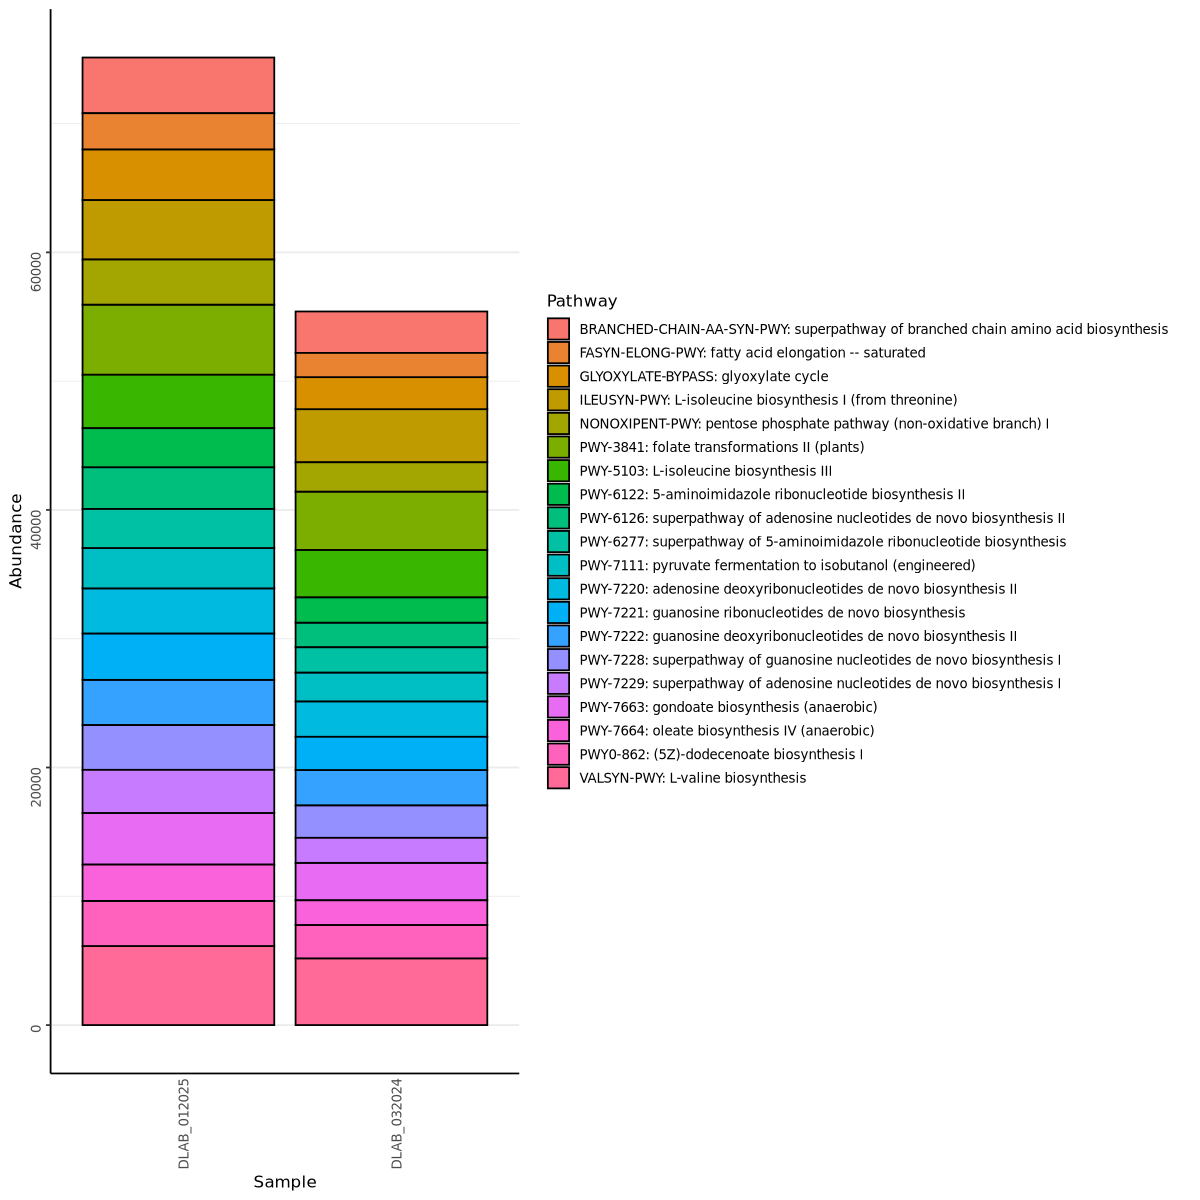

In [71]:
dlab_pathway_plot_20<- df_pathway_dlab_20_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position="right", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=10), legend.key.size = unit(0.5, "cm"))
#theme(aspect.ratio = 1.5)

dlab_pathway_plot_20

In [72]:
ggsave(filename = "dlab_pathway_plot_20_cpm.png", plot = dlab_pathway_plot_20, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

In [73]:
df_pathway_dlab_20_rel <- as.data.frame(dlab_top_20_m) %>%
  mutate(across(where(is.numeric), ~ .x / sum(.x)))
head(df_pathway_dlab_20_rel)

,Pathway,DLAB_032024,DLAB_012025
,<chr>,<dbl>,<dbl>
863,VALSYN-PWY: L-valine biosynthesis,0.09351605,0.08170797
260,PWY-3841: folate transformations II (plants),0.08189751,0.07248427
151,ILEUSYN-PWY: L-isoleucine biosynthesis I (from threonine),0.07446108,0.06155398
286,PWY-5103: L-isoleucine biosynthesis III,0.06641858,0.05525117
39,BRANCHED-CHAIN-AA-SYN-PWY: superpathway of branched chain amino acid biosynthesis,0.05806042,0.05759120
674,PWY-7663: gondoate biosynthesis (anaerobic),0.05254838,0.05338771


In [74]:
df_pathway_dlab_20_rel_long <- df_pathway_dlab_20_rel %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

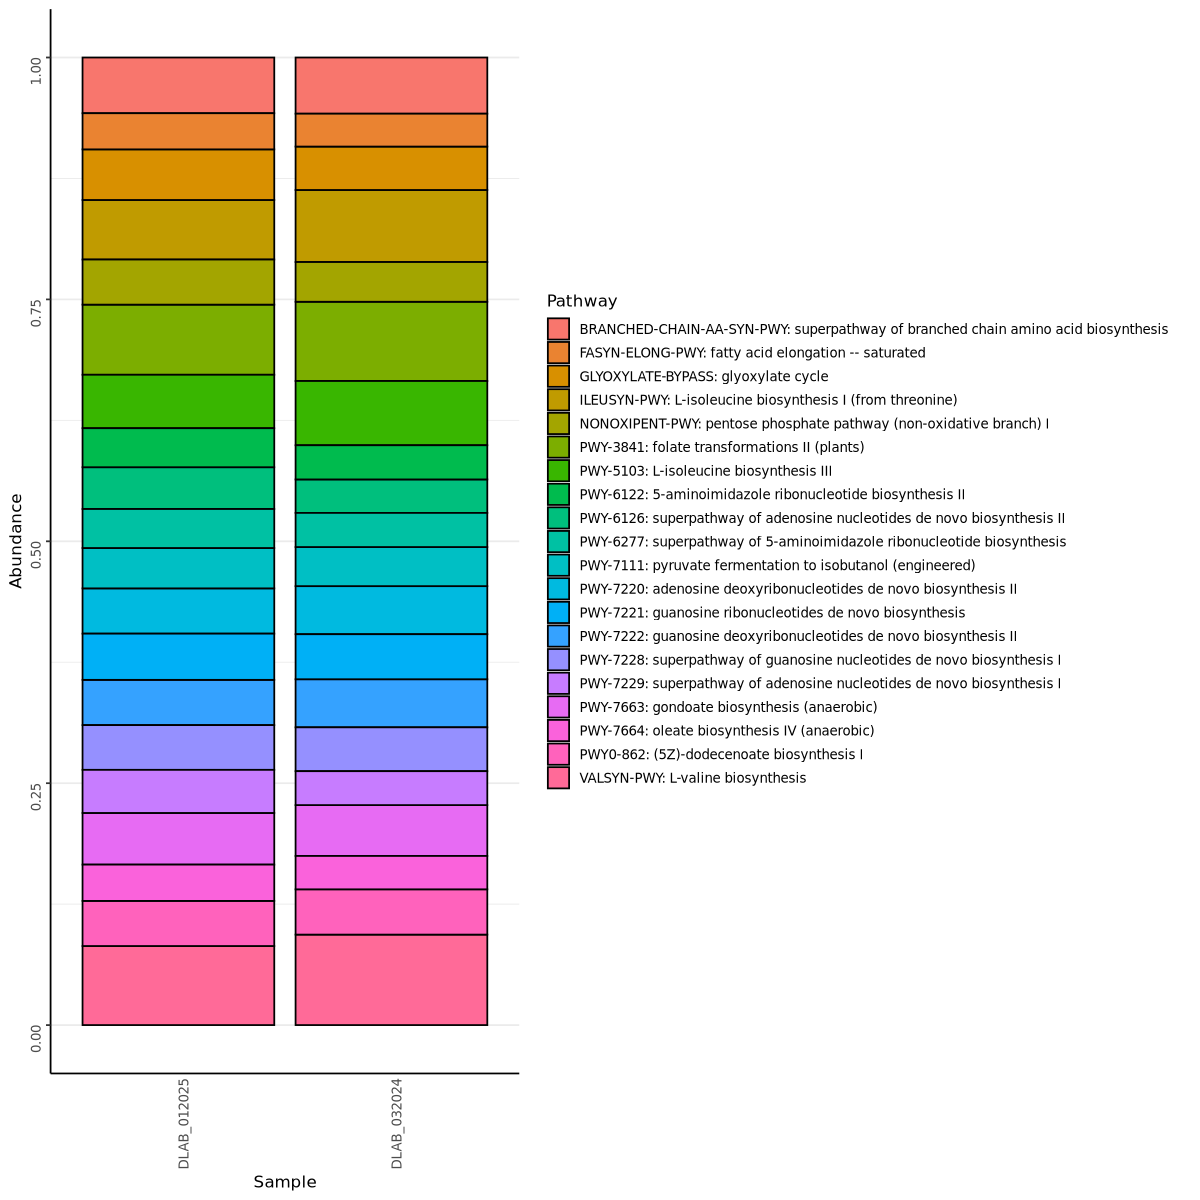

In [75]:
dlab_pathway_plot_20_rel<- df_pathway_dlab_20_rel_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position="right", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=10), legend.key.size = unit(0.5, "cm"))
#theme(aspect.ratio = 1.5)

dlab_pathway_plot_20_rel

In [76]:
ggsave(filename = "dlab_pathway_plot_20_rel_cpm.png", plot = dlab_pathway_plot_20_rel, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

### PSTRs

In [84]:
#look at just pstrs
pstr_pathways <- subset(pathway_totals_ready, select = c(Pathway, PSTR_032024, PSTR_012025))
head(pstr_pathways)
#remove rows with zeros (in columns 2 and 3)
pstr_pathways_num <- pstr_pathways[rowSums(pstr_pathways[, c(2,3)] == 0) < 2, ]
head(pstr_pathways_num)
dim(pstr_pathways_num)

,Pathway,PSTR_032024,PSTR_012025
,<chr>,<dbl>,<dbl>
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0.000,23.4657
8,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0.000,0.0000
10,1CMET2-PWY: folate transformations III (E. coli),157.737,89.4499
14,ANAEROFRUCAT-PWY: homolactic fermentation,0.000,73.5769
16,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0.000,158.2889
18,ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0.000,72.5046


,Pathway,PSTR_032024,PSTR_012025
,<chr>,<dbl>,<dbl>
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0.0000,23.4657
10,1CMET2-PWY: folate transformations III (E. coli),157.7370,89.4499
14,ANAEROFRUCAT-PWY: homolactic fermentation,0.0000,73.5769
16,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0.0000,158.2889
18,ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0.0000,72.5046
20,ARGININE-SYN4-PWY: L-ornithine biosynthesis II,162.8824,162.1210


[1] 274   3

In [78]:
df_pathway_pstr_long <- pstr_pathways_num %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

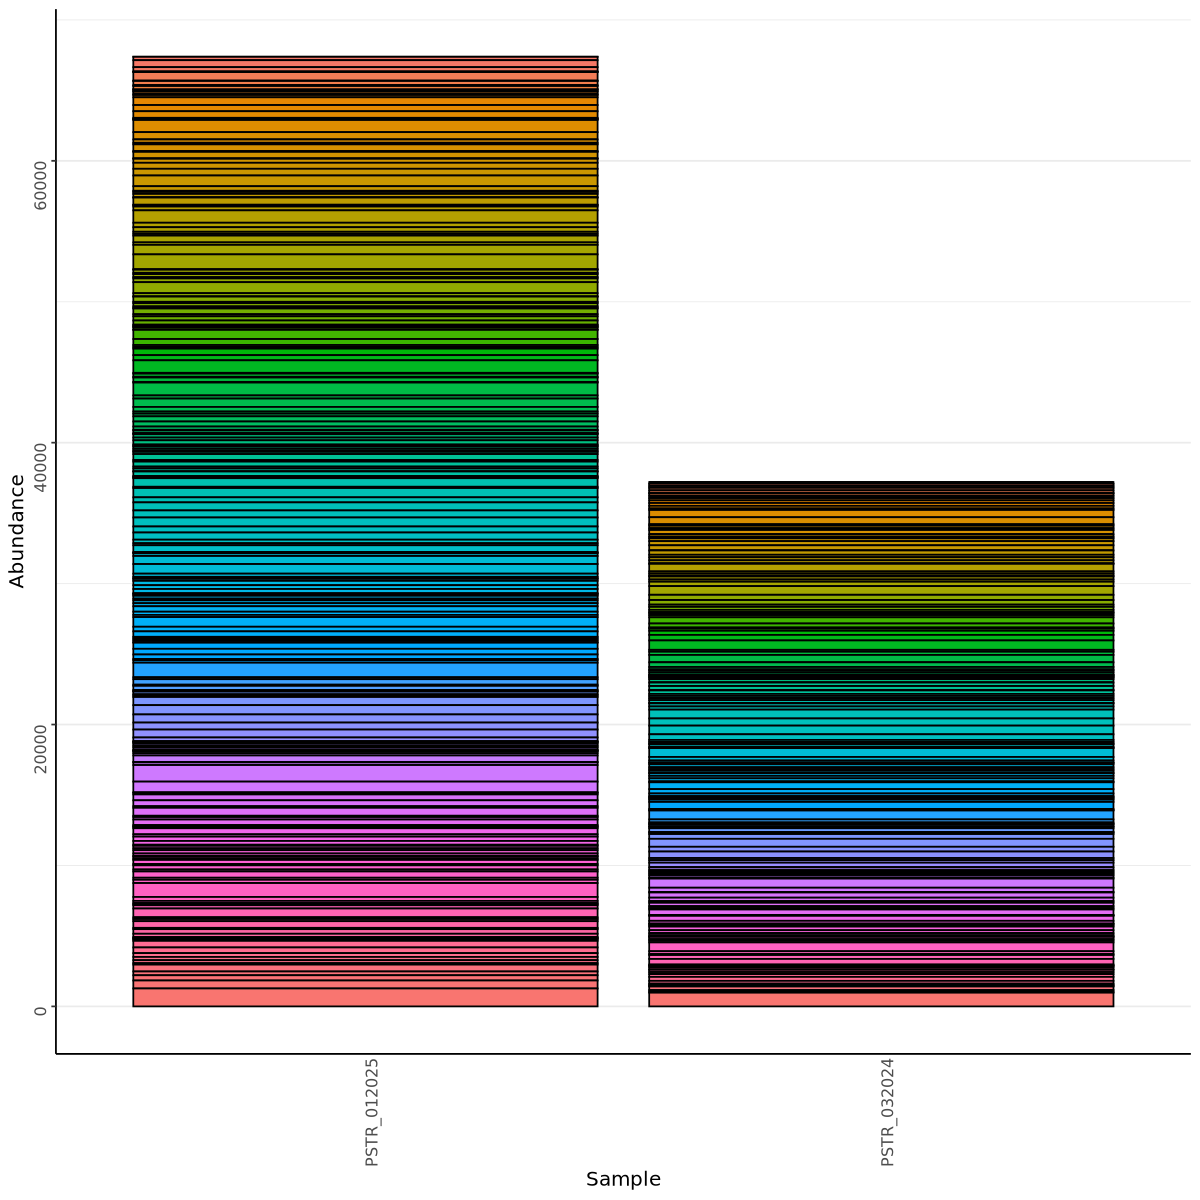

In [79]:
#without legend - need to play with sizing
pstr_pathway_plot_l<- df_pathway_pstr_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position="none", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12)) 
pstr_pathway_plot_l

In [80]:
# index the Pathways
row.names(pstr_pathways_num) <- pstr_pathways_num$Pathway
pstr_pathways_num$Pathway <- NULL
head(pstr_pathways_num)

,PSTR_032024,PSTR_012025
,<dbl>,<dbl>
"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0.0000,23.4657
1CMET2-PWY: folate transformations III (E. coli),157.7370,89.4499
ANAEROFRUCAT-PWY: homolactic fermentation,0.0000,73.5769
ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0.0000,158.2889
ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0.0000,72.5046
ARGININE-SYN4-PWY: L-ornithine biosynthesis II,162.8824,162.1210


In [81]:
# Convert to matrix
pstr_pathways_matrix=as.matrix(pstr_pathways_num)
head(pstr_pathways_matrix)

,PSTR_032024,PSTR_012025
"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0.0000,23.4657
1CMET2-PWY: folate transformations III (E. coli),157.7370,89.4499
ANAEROFRUCAT-PWY: homolactic fermentation,0.0000,73.5769
ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0.0000,158.2889
ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0.0000,72.5046
ARGININE-SYN4-PWY: L-ornithine biosynthesis II,162.8824,162.1210


In [82]:
#calculate totals
pathway_totals_p <- rowSums(pstr_pathways_matrix)

In [83]:
#take the top 20 pathways
pstr_top_20 <- order(pathway_totals_p, decreasing = TRUE)[1:20]
head(pstr_top_20)

[1] 274 209  45 171 245  80

In [85]:
#need to do this from an unindexed dataframe, so re-run step where I first make the ofav_pathways_num df
    #before doing this part!
#pull the top 20 out of the full matrix
pstr_top_20_m <- pstr_pathways_num[pstr_top_20, ]
head(pstr_top_20_m)

,Pathway,PSTR_032024,PSTR_012025
,<chr>,<dbl>,<dbl>
863,VALSYN-PWY: L-valine biosynthesis,973.2773,1272.0122
674,PWY-7663: gondoate biosynthesis (anaerobic),645.7052,1174.9341
151,ILEUSYN-PWY: L-isoleucine biosynthesis I (from threonine),621.2447,1050.7328
552,PWY-7111: pyruvate fermentation to isobutanol (engineered),632.8052,1030.9983
776,PWY0-862: (5Z)-dodecenoate biosynthesis I,624.5572,985.8659
260,PWY-3841: folate transformations II (plants),667.3297,887.2297


In [86]:
df_pathway_pstr_20_long <- pstr_top_20_m %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

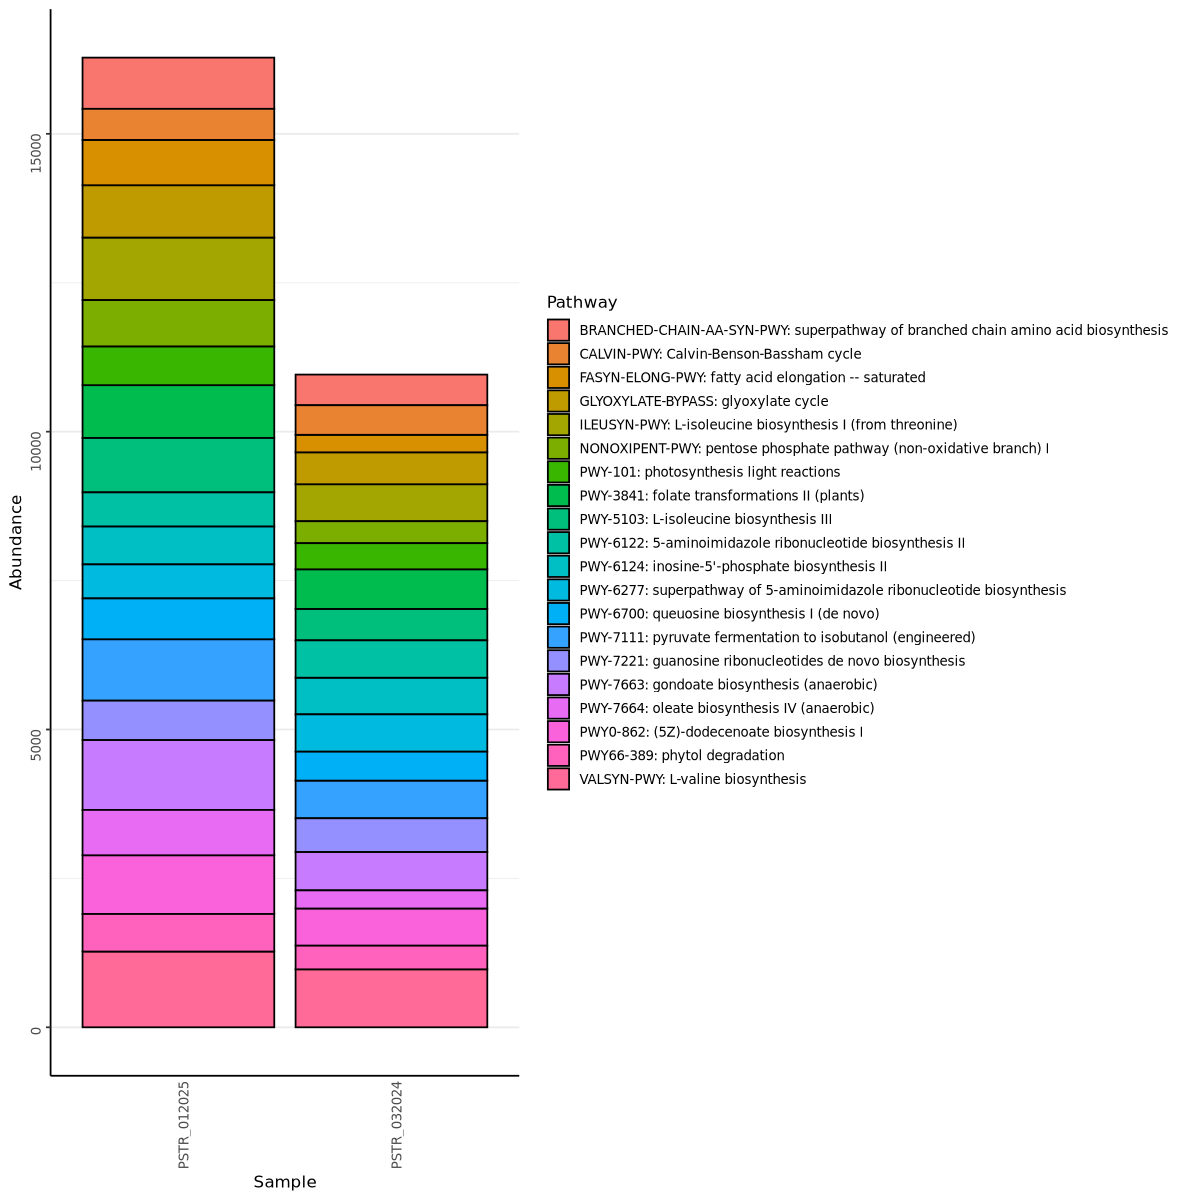

In [87]:
pstr_pathway_plot_20<- df_pathway_pstr_20_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position="right", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=10), legend.key.size = unit(0.5, "cm"))
#theme(aspect.ratio = 1.5)

pstr_pathway_plot_20

In [88]:
ggsave(filename = "pstr_pathway_plot_20_cpm.png", plot = pstr_pathway_plot_20, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

In [89]:
df_pathway_pstr_20_rel <- as.data.frame(pstr_top_20_m) %>%
  mutate(across(where(is.numeric), ~ .x / sum(.x)))
head(df_pathway_pstr_20_rel)

,Pathway,PSTR_032024,PSTR_012025
,<chr>,<dbl>,<dbl>
863,VALSYN-PWY: L-valine biosynthesis,0.08881521,0.07813474
674,PWY-7663: gondoate biosynthesis (anaerobic),0.05892303,0.07217161
151,ILEUSYN-PWY: L-isoleucine biosynthesis I (from threonine),0.05669091,0.06454241
552,PWY-7111: pyruvate fermentation to isobutanol (engineered),0.05774585,0.06333020
776,PWY0-862: (5Z)-dodecenoate biosynthesis I,0.05699319,0.06055789
260,PWY-3841: folate transformations II (plants),0.06089634,0.05449906


In [90]:
df_pathway_pstr_20_rel_long <- df_pathway_pstr_20_rel %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

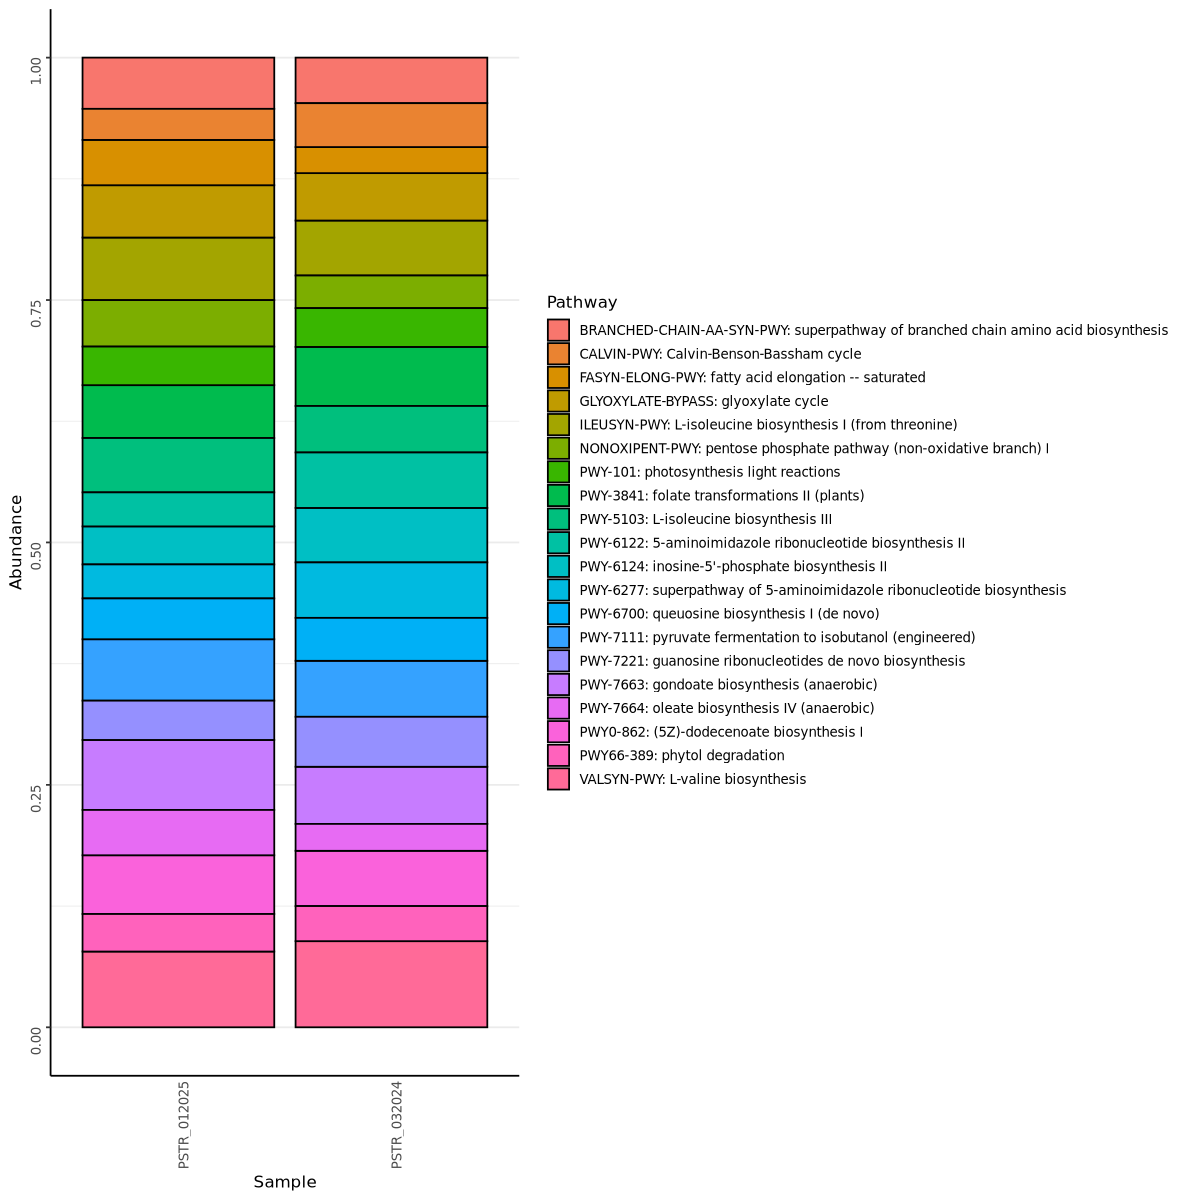

In [91]:
pstr_pathway_plot_20_rel<- df_pathway_pstr_20_rel_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position="right", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=10), legend.key.size = unit(0.5, "cm"))
#theme(aspect.ratio = 1.5)

pstr_pathway_plot_20_rel

In [92]:
ggsave(filename = "pstr_pathway_plot_20_rel_cpm.png", plot = pstr_pathway_plot_20_rel, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

### Pathways of interest between species

In [1]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/humann3_functional_analysis_032024_012025/pathways")

In [102]:
select_pathways <- read.csv("select_pathways_of_interest_CPM.csv")

In [103]:
head(select_pathways)

,Pathway,OFAV_032024,OFAV_012025,MCAV_032024,MCAV_012025,DLAB_032024,DLAB_012025,PSTR_032024,PSTR_012025
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,BIOTIN-BIOSYNTHESIS-PWY: biotin biosynthesis I,0.0000,0.0000,0.000,0.0000,227.3040,178.0169,0.0000,62.5737
2,COA-PWY-1: superpathway of coenzyme A biosynthesis III (mammals),0.0000,0.0000,168.279,134.3400,360.0773,718.5329,131.1519,113.8900
3,COA-PWY: coenzyme A biosynthesis I (prokaryotic),60.7945,30.8338,990.193,321.3610,1107.8162,1880.9380,310.0859,474.2181
4,COBALSYN-PWY: superpathway of adenosylcobalamin salvage from cobinamide I,0.0000,0.0000,0.000,0.0000,64.1237,223.1939,0.0000,0.0000
5,P101-PWY: ectoine biosynthesis,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,17.4744
6,PANTOSYN-PWY: superpathway of coenzyme A biosynthesis I (bacteria),0.0000,0.0000,236.059,226.3678,319.3186,844.2870,155.4148,151.9518


In [104]:
select_pathways_long <- select_pathways %>%
  pivot_longer(-Pathway, names_to = "Samples", values_to = "Abundance")

In [105]:
colors_17 <- c("#4477AA",
  "#5197C4",
  "#5EB7DD",
  "#5EC4D7",
  "#44AA91",
  "#2A914A",
  "#4D9537",
  "#8CA83E",
  "#CCBB44",
  "#D99B57",
  "#E67B6A",
  "#E66077",
  "#CC4D77",
  "#B33977",
  "#AE5588",
  "#B588A2",
  "#BBBBBB")

In [106]:
options(repr.plot.width=10, repr.plot.height=10)

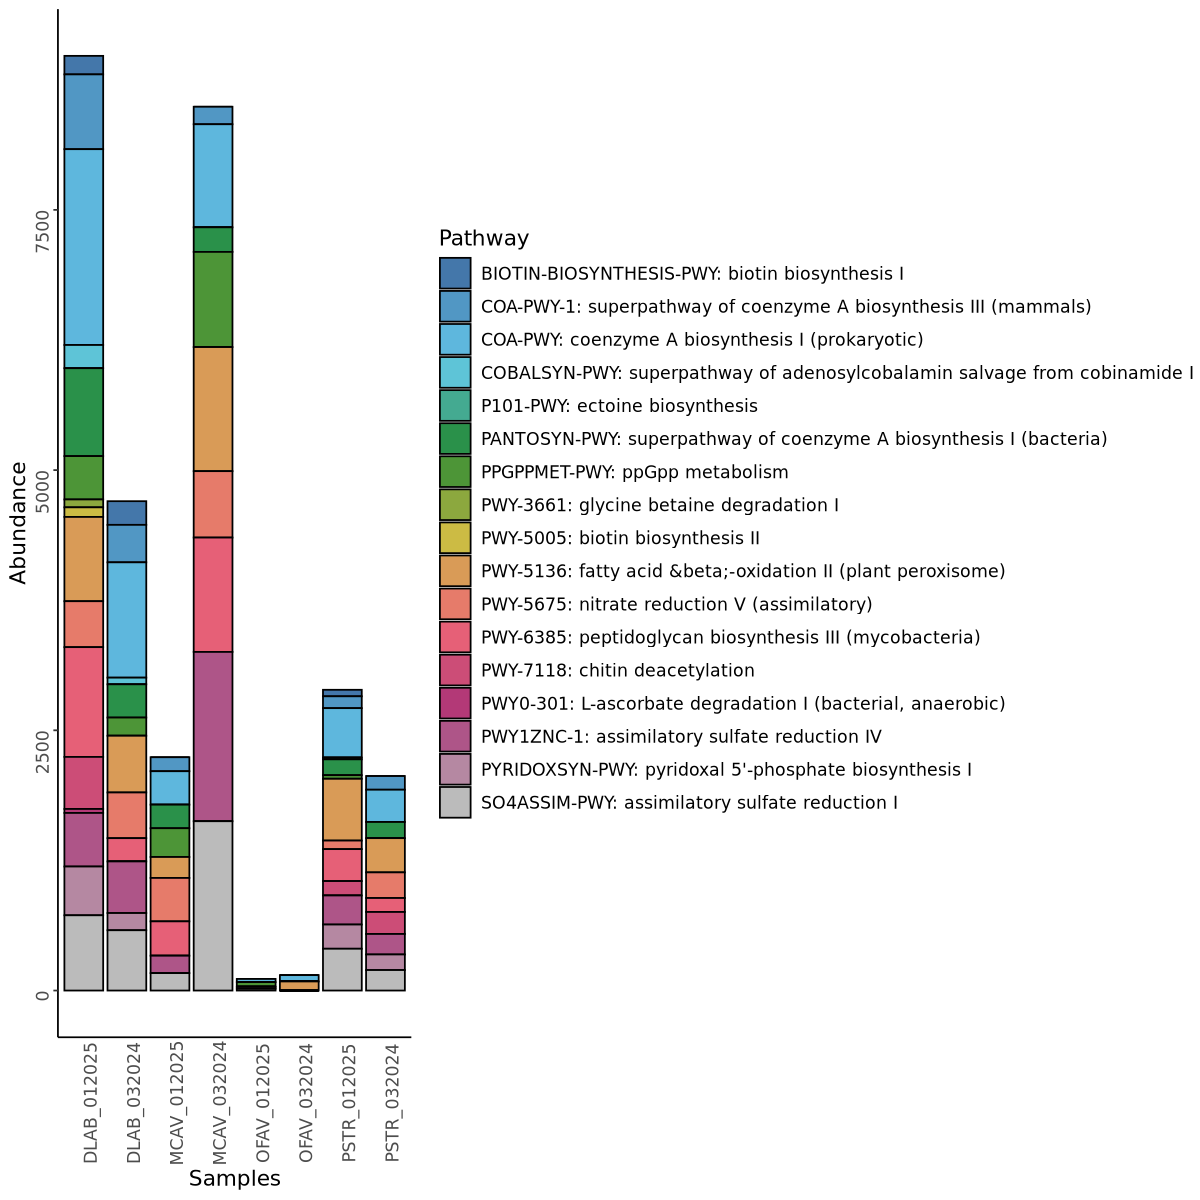

In [107]:
select_pathways_plot<- select_pathways_long %>%
  ggplot(aes(x = Samples, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  scale_fill_manual(values = colors_17)+
  theme_bw() +
  theme(legend.position="right", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(),
          panel.grid.minor.y = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=13), legend.key.size = unit(0.7, "cm"))
#theme(aspect.ratio = 1.5)

select_pathways_plot

In [108]:
ggsave(filename = "select_pathways_plot_cpm.png", plot = select_pathways_plot, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)